In [1]:
import pandas as pd
import numpy as np

import shap

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns
import os
import math
from datetime import date
from tqdm import tqdm
from collections import Counter
import psutil
import shutil
import gc
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import silhouette_score, davies_bouldin_score
from lightgbm import LGBMRanker, early_stopping, log_evaluation
from xgboost import XGBRanker
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
tqdm.pandas()

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 20)

<!--
<h1 style="color: #4682B4;">CONSTANTS</h1>
<h1 style="color: #8FBC8F;">CONSTANTS</h1>
-->
<!--
<h1 style="color: #2D5A27; font-size: 2.6em; font-weight: 800; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; letter-spacing: 1.5px; border-bottom: 3px solid #2D5A27; padding-bottom: 8px;">CONSTANTS AND FLAGS</h1>

<h1 style="color: #2D5A27; font-size: 2.3em; font-weight: 700; text-transform: uppercase; letter-spacing: 1px; border-left: 6px solid #2D5A27; padding-left: 15px;">CONSTANTS AND FLAGS</h1>

<h1 style="color: #2D5A27; font-size: 2.5em; font-weight: bold; background-color: #F0F7F4; padding: 15px 20px; border-left: 8px solid #2D5A27; border-radius: 0 6px 6px 0;">CONSTANTS AND FLAGS</h1>

<div style="background-color: #f8f9fa; border-left: 5px solid #2D5A27; padding: 15px; margin-bottom: 20px;">
    <h1 style="color: #2D5A27; font-size: 32px; margin: 0; font-family: sans-serif; letter-spacing: 1px; text-transform: uppercase;">
        Constants and Flags
    </h1>
    <p style="color: #999; font-size: 14px; margin: 5px 0 0 0;">Configuration & Global Parameters</p>
</div>
-->
<!--
<h1 style="color: #10B981;">CONSTANTS</h1>
<h1 style="color: #8A2BE2;">CONSTANTS</h1>
<h1 style="color: #212529;">CONSTANTS</h1>
<h1 style="color: #1C1A27;">CONSTANTS</h1>
<h1 style="color: #2A2421;">CONSTANTS</h1>
<h1 style="color: #0B192C;">CONSTANTS</h1>
<h1 style="color: #00D2C4;">CONSTANTS</h1>
<h1 style="color: #008080;">CONSTANTS</h1>
<h1 style="color: #FFDE21;">CONSTANTS</h1>
<h1 style="color: #F9CC5C;">CONSTANTS</h1>
<h1 style="color: #FDDA0D;">CONSTANTS</h1>
-->

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
    CONSTANTS AND FLAGS
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Configuration & Global Parameters
    </p>
</div>

In [3]:
# ============================================================
# KONSTANTE — Apriori flagovi
# ============================================================
USE_APRIORI_AS_FEATURE = True  # True → candidate_apriori_score ulazi u LGBM/XGB
BLEND_APRIORI          = False # True → apriori score ulazi u blend kao 4. weight
BLEND_MARKOV_PROBS     = False
INCLUDE_SEGMENT_MARKOV = True
USE_MARKOV_PROBS_AS_FEATURE = True
INCLUDE_CLIENT_CLUSTERS = True

INCLUDE_RENEWAL_FEATURES = True
INCLUDE_SEASONAL_FEATURES = True
INCLUDE_POPULARITY_FEATURES = True

DO_NEGATIVE_SAMPLING = False


# Ucesce loss funkcija prilikom optuna optimizacije
# HR3_WEIGHT = 0.75
# MRR5_WEIGHT = 0.25
HR3_WEIGHT = 0.55
MRR5_WEIGHT = 0.45

OPTUNA_NTRIALS = 75

APRIORI_MIN_SUPP = 0.005
APRIORI_MIN_CONFIDENCE = 0.15


# Ova dva se međusobno isključuju — ako su oba True, feature mod ima prioritet
assert not (USE_APRIORI_AS_FEATURE and BLEND_APRIORI), \
    "Odaberi jedan mod: USE_APRIORI_AS_FEATURE ili BLEND_APRIORI, ne oba."

In [4]:
# Provjera konzistentnosti flagova
assert not (USE_APRIORI_AS_FEATURE and BLEND_APRIORI), \
    "Odaberi jedan mod: USE_APRIORI_AS_FEATURE ili BLEND_APRIORI, ne oba."

assert abs(HR3_WEIGHT + MRR5_WEIGHT - 1.0) < 1e-9, \
    f"HR3_WEIGHT + MRR5_WEIGHT mora biti 1.0, trenutno: {HR3_WEIGHT + MRR5_WEIGHT}"

assert 0.0 <= HR3_WEIGHT <= 1.0 and 0.0 <= MRR5_WEIGHT <= 1.0, \
    "Weightovi moraju biti između 0 i 1."

print("✅ Konstante validne:")
print(f"   USE_APRIORI_AS_FEATURE = {USE_APRIORI_AS_FEATURE}")
print(f"   BLEND_APRIORI          = {BLEND_APRIORI}")
print(f"   BLEND_MARKOV_PROBS     = {BLEND_MARKOV_PROBS}")
print(f"   INCLUDE_SEGMENT_MARKOV = {INCLUDE_SEGMENT_MARKOV}")
print(f"   USE_MARKOV_PROBS_AS_FEATURE   = {USE_MARKOV_PROBS_AS_FEATURE}")
print(f"   INCLUDE_CLIENT_CLUSTERS= {INCLUDE_CLIENT_CLUSTERS}")
print(f"   INCLUDE_RENEWAL_FEATURES= {INCLUDE_RENEWAL_FEATURES}")
print(f"   INCLUDE_SEASONAL_FEATURES= {INCLUDE_SEASONAL_FEATURES}")
print(f"   INCLUDE_POPULARITY_FEATURES= {INCLUDE_POPULARITY_FEATURES}")
print(f"   DO_NEGATIVE_SAMPLING= {DO_NEGATIVE_SAMPLING}")
print(f"   Optuna loss: {HR3_WEIGHT}×HR@3 + {MRR5_WEIGHT}×MRR@5")

✅ Konstante validne:
   USE_APRIORI_AS_FEATURE = True
   BLEND_APRIORI          = False
   BLEND_MARKOV_PROBS     = False
   INCLUDE_SEGMENT_MARKOV = True
   USE_MARKOV_PROBS_AS_FEATURE   = True
   INCLUDE_CLIENT_CLUSTERS= True
   INCLUDE_RENEWAL_FEATURES= True
   INCLUDE_SEASONAL_FEATURES= True
   INCLUDE_POPULARITY_FEATURES= True
   DO_NEGATIVE_SAMPLING= False
   Optuna loss: 0.55×HR@3 + 0.45×MRR@5


<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   LOADING TRAINING DATA
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <p style="color: #222; font-size: 14px; margin: 0; font-family: sans-serif;">
        Insurance policy data
    </p>
</div>

In [5]:
# # ============================================================
# # UCITAVANJE PODATAKA
# # ============================================================

# policy_data = pd.read_csv('../../data/data_from_db_as_csv/new_polisa_202603141519.csv', dtype={
#     'ponuda_id': 'Int32', 'ugo_jmbg': str
# })
# ins_cli_data = pd.read_csv('../../data/data_from_db_as_csv/__ins_klijenti__202603141320.csv', dtype={
#     'mat_br': str, 'klijent_id': 'Int32'
# })
# np_cli_data = pd.read_csv('../../data/data_from_db_as_csv/new_polisa_klijent_202603141515.csv', dtype={
#     'osig_jmbg': str, 'klijent_id': 'Int32', 'ponuda_id': 'Int32'
# })
# cli_roles = pd.read_csv('../../data/data_from_db_as_csv/new_polisa_uloga_202603172039.csv')

In [6]:
# ============================================================
# UCITAVANJE PODATAKA
# ============================================================

policy_data = pd.read_csv('../../data/data_from_db_as_csv/production/new_polisa_202606051446.csv', dtype={
    'ponuda_id': 'Int32', 'ugo_jmbg': str
})

ins_cli_data = pd.read_csv('../../data/data_from_db_as_csv/production/__ins_klijenti__202606051502.csv', dtype={
    'mat_br': str, 'klijent_id': 'Int32'
})

np_cli_data = pd.read_csv('../../data/data_from_db_as_csv/production/new_polisa_klijent_202606051445.csv', dtype={
    'osig_jmbg': str, 'klijent_id': 'Int32', 'ponuda_id': 'Int32'
})

cli_roles = pd.read_csv('../../data/data_from_db_as_csv/production/new_polisa_uloga_202606051502.csv')

policy_types = pd.read_csv('../../data/data_from_db_as_csv/production/tsif_vrsta_202606051502.csv')

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_10368\3161640843.py:5: DtypeWarning: Columns (61,65,80,82) have mixed types. Specify dtype option on import or set low_memory=False.
  policy_data = pd.read_csv('../../data/data_from_db_as_csv/production/new_polisa_202606051446.csv', dtype={
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_10368\3161640843.py:9: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  ins_cli_data = pd.read_csv('../../data/data_from_db_as_csv/production/__ins_klijenti__202606051502.csv', dtype={
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_10368\3161640843.py:13: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  np_cli_data = pd.read_csv('../../data/data_from_db_as_csv/production/new_polisa_klijent_202606051445.csv', dtype={


<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   DEBBUGING FUNCTIONS
</h2>

<div style="background-color: #f8f9fa; border-left: 4px solid #2D5A27; padding: 10px 15px; margin-top: 0; margin-bottom: 20px;">
    <ul>
        <li>Calculate RAM memory usage</li>
        <li>Print duplicate columns</li>
        <li>Showing policy client distribution (Does client have one policy or more)</li>
    </ul>
</div>

In [7]:
# ============================================================
# POMOCNE FUNKCIJE
# ============================================================
process = psutil.Process(os.getpid())

def get_ram_mb():
    return process.memory_info().rss / 1024 / 1024

def print_duplicates(df, subset):
    print(f"\n### DUPLICATES: {subset} ###")

    # Po defaultu je keep='first'
    print(f"Dupliranih redova: {df.duplicated(subset=subset, keep='first').sum()}")
    print(f"Jedinstvenih duplikata: {df.groupby(subset).size().gt(1).sum()}")
    print(f"Ukupno redova u dupliranim grupama: {df.duplicated(subset=subset, keep=False).sum()}")

def show_cli_policy_distribution(df):
    sns.set_style("darkgrid")
    
    policy_counts = df.groupby('klijent_id').size()
    
    data = {"Only 1 policy": (policy_counts == 1).sum(),
            "More than 1 policy": (policy_counts > 1).sum()}
    
    plot_df = pd.DataFrame({"category": list(data.keys()), "value": list(data.values())})
    
    plt.figure(figsize=(8, 6))
    
    ax = sns.barplot(data=plot_df, x="category", y="value", hue="category",
                     palette=["#4C78A8", "#F58518"], legend=False)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=11)
        
    plt.title("Distribution of Clients by Number of Policies", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

<h2 style="color: #2D5A27; font-size: 26px; font-weight: bold; font-family: sans-serif; letter-spacing: 0.5px; margin-bottom: 5px;">
   CLEANING DATA
</h2>

<h3>Realise date manipulation</h3>

In [8]:
# ============================================================
# CISCENJE POLICY DATA
# ============================================================
policy_data = policy_data[(policy_data['polisa_id'].notna() & policy_data['polisa_id'] != 0)]
policy_data = policy_data.drop_duplicates('polisa_id', keep='first')
policy_data['dat_izdavanja'] = pd.to_datetime(policy_data['dat_izdavanja'])
policy_data['godina']    = policy_data['dat_izdavanja'].dt.year
policy_data['days_old']  = (pd.Timestamp.today() - policy_data['dat_izdavanja']).dt.days
policy_data['years_old'] = policy_data['days_old'] / 365.25

<h2 style="color: #008080;">Collecting as much information as possible for each client</h2>

In [9]:
# ============================================================
# KLIJENTI
# ============================================================
def gather_cli_info_fastest(df):
    df = df.sort_values('klijent_id')
    df_filled = df.groupby('klijent_id').transform('bfill')
    df_filled['klijent_id'] = df['klijent_id'].values
    return df_filled.drop_duplicates('klijent_id', keep='first')

In [10]:
def extract_serial_num_data(serial_number):
    
    if pd.isna(serial_number) or serial_number == '' or len(serial_number) != 13:
        return np.nan, np.nan, np.nan
        
    sn = str(serial_number).zfill(13)
    year = int(sn[4:7])
    year = year + 2000 if year < 800 else 1000 + year
    age = date.today().year - year
    birth_place = sn[7:9]
    gender = 1 if int(sn[9:12]) < 500 else 0
    return age, birth_place, gender

def clear_data(df):
    
    df = df.copy()

    # stranac
    df['is_foreign'] = df['br_pasosa_y'].apply(lambda x: 1 if pd.notna(x) and x != '' else 0)
    df['ind_rezident'] = df['ind_rezident'].apply(lambda x: 1 if x == 'D' else 0)
    df['ind_stranac']  = df['ind_stranac'].apply(lambda x: 1 if x == 'D' else 0)
    df['is_foreign'] = df['is_foreign'].fillna(df['ind_rezident']).fillna(df['ind_stranac'])
    
    df.drop(['ind_rezident', 'ind_stranac', 'drzava_id_x', 'drzava_id_y',
             'br_pasosa_x', 'br_pasosa_y'], axis=1, inplace=True)

    # svojina
    df['ownerType'] = df['sif_svojina'].fillna(df['osig_svojina'])
    df.loc[df['ownerType'] == 2, 'ownerType'] = 0
    
    df.drop(['sif_svojina', 'osig_svojina'], axis=1, inplace=True)
    df[['age', 'birth_place', 'gender']] = (
        df.loc[(df['ownerType'] == 1) & (df['is_foreign'] == 0), 'mat_br']
        .apply(extract_serial_num_data).apply(pd.Series)
    )

    # godine
    df['datum_rodjenja'] = pd.to_datetime(
        df['datum_rodjenja_x'].fillna(df['datum_rodjenja_y']), errors='coerce'
    )
    df['years'] = date.today().year - df['datum_rodjenja'].dt.year
    df['age']   = df['age'].fillna(df['years'])
    
    df.drop(['datum_rodjenja_x', 'datum_rodjenja_y', 'datum_rodjenja', 'years'], axis=1, inplace=True)

    # pol
    df.loc[df['pol_id_x'] == 2, 'pol_id_x'] = 0
    df.loc[df['pol_id_y'] == 2, 'pol_id_y'] = 0
    df['gender'] = df['gender'].fillna(df['pol_id_x']).fillna(df['pol_id_y'])
    
    df.drop(['pol_id_x', 'pol_id_y'], axis=1, inplace=True)

    # bracni status
    df['merrige_status'] = df['sif_bracni_status_x'].fillna(df['sif_bracni_status_y'])
    df.loc[df['merrige_status'] == 2, 'merrige_status'] = 0
    
    df.drop(['sif_bracni_status_x', 'sif_bracni_status_y'], axis=1, inplace=True)

    # posao
    df['unknown_job'] = df['nedef_delatnost_y'].fillna(df['nedef_delatnost_x'])
    
    df.drop(['nedef_delatnost_y', 'nedef_delatnost_x'], axis=1, inplace=True)
    
    df['job_type'] = df['sif_delatnost_y'].fillna(df['sif_delatnost_x'])
    
    df.drop(['sif_delatnost_y', 'sif_delatnost_x'], axis=1, inplace=True)

    # Vozacka dozvola
    df['driving_licence_date'] = df['dat_vozacke_y'].fillna(df['dat_vozacke_x'])
    df.drop(['dat_vozacke_y', 'dat_vozacke_x'], axis=1, inplace=True)
    
    text_cols = [
        'mat_br', 'naziv', 'naziv1', 'king_id_x', 'mesto_rodj_x', 'osig_jmbg', 'osig_naziv',
        'osig_naziv1', 'osig_ulica', 'osig_mesto', 'osig_telefon2', 'ind_info_ponuda',
        'king_id_y', 'osig_telefon1', 'osig_mail', 'mesto_rodj_y', 'procenat', 'sif_mj'
    ]
    
    df.drop([c for c in text_cols if c in df.columns], axis=1, inplace=True)
    return df

def feature_engineering(df):
    
    df = df.copy()

    # Grupe po godinama
    df['age_bucket'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 65, 100], labels=[0, 1, 2, 3, 4])

    # Koliko dugo vozi + popunjavanje praznih redova
    df['driving_licence_date'] = pd.to_datetime(df['driving_licence_date'], errors='coerce')
    today_year = pd.Timestamp.today().year
    df['driving_experience'] = (today_year - df['driving_licence_date'].dt.year).astype(float)
    df['driving_experience'] = (
        df['driving_experience']
        .fillna(df.groupby('age_bucket', observed=True)['driving_experience'].transform('median'))
        .fillna(df['driving_experience'].median())
    )

    # Bracni status popunjavanje praznih redova
    df['merrige_status'] = df['merrige_status'].astype(float)
    df['merrige_status'] = (
        df['merrige_status']
        .fillna(df.groupby('age_bucket', observed=True)['merrige_status'].transform('median'))
        .fillna(df['merrige_status'].median())
    )
    
    df = df.drop('driving_licence_date', axis=1)
    return df

In [11]:
# Procentualna popunjenost izabranih kolona
def plot_column_fill_rate(df, cols):
    fill_rate = df[cols].notna().mean() * 100

    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        x=fill_rate.values,
        y=fill_rate.index
    )

    ax.set_xlabel('Popunjenost (%)')
    ax.set_ylabel('Kolona')
    ax.set_title('Procenat popunjenosti kolona')

    plt.tight_layout()
    plt.show()

Ukupno kolona:  16


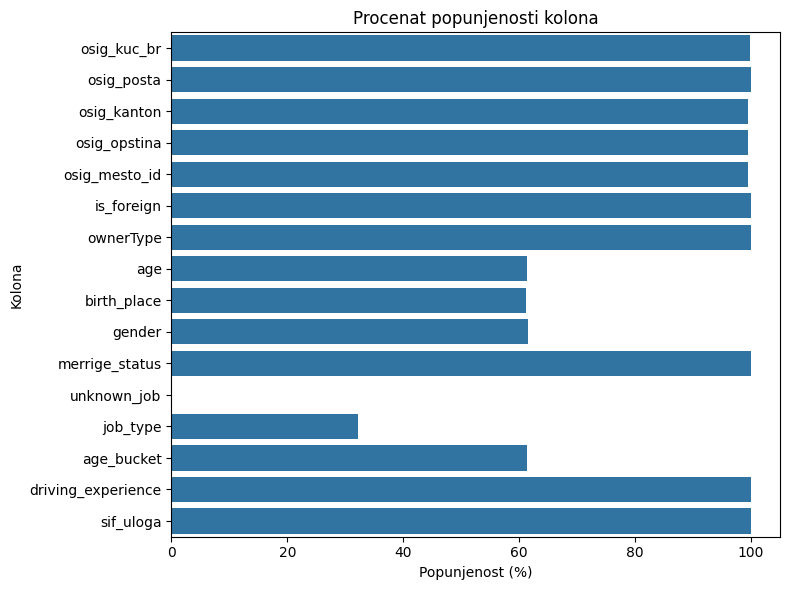

In [12]:
# ============================================================
# KLIJENTI PROCESUIRANJE
# ============================================================
cli_data = ins_cli_data.merge(np_cli_data, on="klijent_id", how="inner")
cli_data = gather_cli_info_fastest(cli_data)
cli_data = clear_data(cli_data)

corrupted_ids = cli_data[(cli_data['age'] < 18) | (cli_data['age'] > 90)]['klijent_id'].values
cli_data.loc[cli_data['klijent_id'].isin(corrupted_ids), 'age'] = \
    cli_data.groupby(['merrige_status', 'osig_opstina'])['age'].transform('median')

cli_data = feature_engineering(cli_data)

cli_data = cli_data.merge(
    np_cli_data[['klijent_id', 'ponuda_id', 'sif_uloga']], on='klijent_id', how='inner'
)
cli_data['ponuda_id'] = cli_data['ponuda_id_y']
cli_data['sif_uloga'] = cli_data['sif_uloga_y']
cli_data = cli_data.drop(['ponuda_id_y', 'ponuda_id_x', 'sif_uloga_y', 'sif_uloga_x'], axis=1)

cli_duplicates = cli_data[cli_data.duplicated(['klijent_id', 'ponuda_id', 'sif_uloga'])].shape[0]
if cli_duplicates > 0:
    cli_data = cli_data.drop_duplicates(['klijent_id', 'ponuda_id', 'sif_uloga'], keep='first')

columns_to_check = [
    c for c in cli_data.columns
    if c not in ['ponuda_id', 'redni_br', 'klijent_id']
]
print("Ukupno kolona: ", len(columns_to_check))
plot_column_fill_rate(cli_data, columns_to_check)

In [13]:
cli_data = cli_data.drop(['unknown_job', 'job_type'], axis=1)

In [14]:
policy_client_data = policy_data.merge(cli_data, on='ponuda_id', how='inner')

cli_roles = cli_roles[cli_roles['opis'].str.contains('Ugovarač', na=False)]

policy_client_data = policy_client_data[
    policy_client_data['sif_uloga'].isin(cli_roles['sif_uloga'].values)
]

In [15]:
def clean_policy_client_data(df):
    cols_to_delete = [
        'sif_preuzmi', 'preuzmi_no', 'preuzmi_id', 'ugo_jmbg', 'ugo_svojina', 'ugo_naziv',
        'ugo_naziv1', 'ugo_ulica', 'ugo_kuc_br', 'ugo_mesto', 'ugo_posta', 'ugo_kanton',
        'ugo_opstina', 'ugo_mesto_id', 'ugo_telefon1', 'ugo_telefon2', 'ugo_mail',
        'osig_jmbg', 'osig_svojina', 'osig_naziv', 'osig_naziv1', 'osig_ulica',
        'osig_kuc_br_x', 'osig_mesto', 'osig_posta_x', 'osig_kanton_x', 'osig_opstina_x',
        'osig_mesto_id_x', 'osig_telefon1', 'osig_telefon2', 'osig_mail', 'mesto_izdavanja',
        'miro_polisa_no', 'sif_ikanton', 'sif_iopstina', 'ugo_del', 'king_id',
        'ugo_br_pasosa', 'osig_br_pasosa', 'registarski_broj_polise', 'akcija_id'
    ]
    return df.drop([c for c in cols_to_delete if c in df.columns], axis=1)

In [16]:
policy_client_data = clean_policy_client_data(policy_client_data)

print(policy_client_data.columns)

Index(['ponuda_id', 'polisa_id', 'sif_vrsta', 'polisa_no', 'broker_id',
       'sif_org_jed', 'zamena_polise_no', 'ind_zamena', 'sif_trajanja',
       'dat_od_ug', 'dat_do_ug', 'dat_od', 'dat_do', 'time_od', 'time_do',
       'br_dana', 'dat_izdavanja', 'mjesto_izdavanja', 'napomena',
       'napomena_auto', 'napomena1', 'p_oper', 'p_date', 'p_session_id',
       'sif_nac_plac', 'br_rata', 'dat_prve_rate', 'sif_napomena',
       'premija_ukupno', 'opis_osiguravac', 'ind_user_skadenca', 'ind_obracun',
       'suma_osiguranja', 'polisa_tarifa', 'veza_polise_no',
       'ind_lock_skadenca', 'uw_indikator', 'ind_uw_kontrola', 'ugo_isprava',
       'osig_isprava', 'sif_datum_dospeca', 'sif_bankovni_racun',
       'konacna_premija', 'ind_nepravilni_otp_plan', 'ind_dug', 'ind_steta',
       'godina', 'days_old', 'years_old', 'redni_br', 'osig_kuc_br_y',
       'osig_posta_y', 'osig_kanton_y', 'osig_opstina_y', 'osig_mesto_id_y',
       'klijent_id', 'is_foreign', 'ownerType', 'age', 'birth_pl

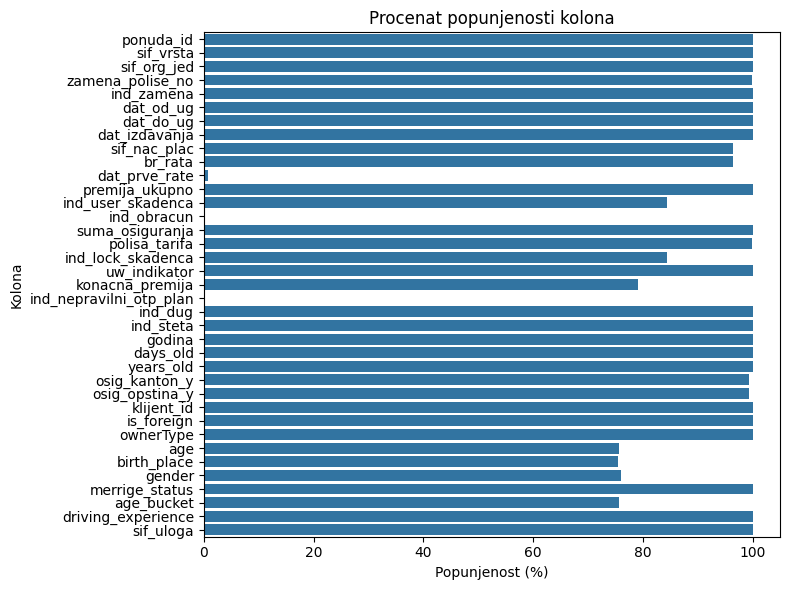

In [17]:
def clean_policy_client_data_2(df):
    cols_to_delete = [
        'polisa_id', 'polisa_no', 'broker_id', 'sif_trajanja',
        # 'dat_od_ug', 'dat_do_ug', 
       'dat_od', 'dat_do', 'time_od', 'time_do',
       'br_dana', 'mjesto_izdavanja', 'napomena',
       'napomena_auto', 'napomena1', 'p_oper', 'p_date', 'p_session_id',  'sif_napomena', 'opis_osiguravac', 
        'veza_polise_no', 'ind_uw_kontrola', 'ugo_isprava',
       'osig_isprava', 'sif_datum_dospeca', 'sif_bankovni_racun', 'redni_br', 'osig_kuc_br_y',
       'osig_posta_y', 
        #'osig_kanton_y', 'osig_opstina_y', 
        'osig_mesto_id_y',
    ]
    
    return df.drop([c for c in cols_to_delete if c in df.columns], axis=1)

policy_client_data = clean_policy_client_data_2(policy_client_data)

cols_to_check = [c for c in policy_client_data.columns if c not in ['ponuda_id', 'klijent_id']]
plot_column_fill_rate(policy_client_data, policy_client_data.columns)

In [18]:
policy_client_data = policy_client_data.drop(['dat_prve_rate', 'ind_obracun', 'ind_nepravilni_otp_plan'], axis = 1)

In [19]:
def process_ussable_data(df):
    df = df.copy()

    zpn = (
        df['zamena_polise_no']
        .notna()
        & (df['zamena_polise_no'] != 0)
    ).astype(int)
    
    binary_mapper = {
        'D': 1,
        'N': 0
    }
    
    df['has_prev_policy'] = (
        df['ind_zamena']
        .map(binary_mapper)
        .fillna(zpn)
        .astype(int)
        )
    
    df = df.drop(['ind_zamena', 'zamena_polise_no'], axis = 1)
    
    df['ind_user_skadenca'] = (
        df['ind_user_skadenca']
        .map(binary_mapper)
        .fillna(0)
        .astype(int)
        )
    
    df = df.drop(['polisa_tarifa', 'ind_lock_skadenca'], axis = 1)
    
    df['uw_indikator'] = (
        df['uw_indikator']
        .map(binary_mapper)
        .fillna(0)
        .astype(int)
        )
    
    df['ind_dug'] = (
        df['ind_dug']
        .map(binary_mapper)
        .fillna(0)
        .astype(int)
        )
    
    df['ind_steta'] = (
        df['ind_steta']
        .map(binary_mapper)
        .fillna(0)
        .astype(int)
        )
    
    return df

policy_client_data = process_ussable_data(policy_client_data)

In [20]:
# ============================================================
# Ciscenje RAM-a
# ============================================================

ins_cli_data = None
np_cli_data  = None
cli_roles    = None
cli_data     = None
gc.collect()

324

<h3>Apriori Association Rules — Kako radi ovaj pipeline</h3>

<p>
Ovaj kod radi <b>two-step recommendation / scoring sistem</b> baziran na
association rules (Apriori).
Ideja je: “ako je klijent imao X tipove polisa, koliko je vjerovatno da će uzeti Y?”
</p>

<hr>

<h4>1. build_apriori_rules() — trening faza (offline učenje pravila)</h4>

<ul>
  <li>Svaki klijent se tretira kao <b>jedna transakcija</b></li>
  <li>Svaka transakcija = set različitih tipova polisa (basket problem)</li>
</ul>

<pre>
baskets = train_df.groupby(CLIENT_COL)['sif_vrsta']
                  .apply(lambda x: list(x.unique()))
</pre>

<p>
👉 Ovo znači: za svakog klijenta uzimamo sve njegove tipove polisa bez duplikata.
</p>

<hr>

<h4>2. TransactionEncoder — pretvaranje u ML format</h4>

<p>
Association rule algoritmi ne rade direktno na listama, nego na “one-hot” matrici.
</p>

<ul>
  <li>svaka kolona = tip polise</li>
  <li>svaki red = klijent</li>
  <li>1 = klijent ima taj tip, 0 = nema</li>
</ul>

<pre>
te = TransactionEncoder()
te_array = te.fit_transform(baskets)
basket_df = pd.DataFrame(te_array, columns=te.columns_)
</pre>

<hr>

<h4>3. Apriori — pronalazak čestih kombinacija</h4>

<pre>
frequent = apriori(basket_df, min_support=min_support)
</pre>

<p>
👉 Ovo traži:
</p>

<blockquote>
Koje kombinacije tipova polisa se često javljaju zajedno među klijentima
</blockquote>

<ul>
  <li>support → koliko često se kombinacija pojavljuje</li>
</ul>

<hr>

<h4>4. association_rules — generisanje pravila</h4>

<pre>
rules = association_rules(frequent, metric="confidence")
</pre>

<p><b>Svako pravilo izgleda ovako:</b></p>

<blockquote>
IF {A, B} → THEN {C}
</blockquote>

<ul>
  <li><b>antecedent</b> = uslov (šta klijent već ima)</li>
  <li><b>consequent</b> = šta se predviđa</li>
  <li><b>confidence</b> = vjerovatnoća</li>
  <li><b>lift</b> = koliko je jača veza od slučajnosti</li>
</ul>

<hr>

<h4>5. apply_apriori_score() — scoring faza (online inference)</h4>

<p>
Za svaki red (klijent, candidate_type) u validation setu:
</p>

<ul>
  <li>uzimamo portfolio klijenta (postojeće polise)</li>
  <li>tražimo pravila koja “gađaju” tog kandidata</li>
</ul>

<hr>

<h4>6. Klijentov portfolio (state feature)</h4>

<pre>
client_portfolio = groupby(client).unique policies
</pre>

<p>
👉 Ovo predstavlja:
</p>

<blockquote>
šta klijent već posjeduje PRIJE predikcije
</blockquote>

<hr>

<h4>7. Matching pravila</h4>

<p>Filtriranje pravila ide u 2 koraka:</p>

<ul>
  <li>consequent mora biti candidate_type</li>
  <li>antecedent mora biti subset klijentovog portfolia</li>
</ul>

<pre>
matching = rules[
    rules['consequents'].apply(lambda c: candidate in c)
]

matching = matching[
    matching['antecedents'].apply(lambda a: a.issubset(portfolio))
]
</pre>

<hr>

<h4>8. Kako se računa score?</h4>

<p>
Ako postoji više pravila, bira se najjače:
</p>

<ul>
  <li>najveći lift</li>
</ul>

<p><b>Finalni score:</b></p>

<pre>
score = confidence * log(1 + lift)
</pre>

<p>
👉 Intuicija:
</p>

<ul>
  <li>confidence = vjerovatnoća pravila</li>
  <li>lift = jačina signala u odnosu na slučajnost</li>
</ul>

<hr>

<h4>9. Šta ovaj model zapravo radi?</h4>

<blockquote>
On ne “uči model” kao ML algoritam,
nego uči skup IF-THEN pravila iz historije korisnika.
</blockquote>

<p>
Zatim ta pravila koristi kao scoring funkciju za ranking kandidata.
</p>

<hr>

<h4>10. Gdje je ovo jako u ML sistemima?</h4>

<ul>
  <li>cold-start preporuke</li>
  <li>recommender sistemi bez dubokog ML-a</li>
  <li>feature engineering za ranking modele</li>
</ul>

<hr>

<h4>11. Ključna intuicija</h4>

<blockquote>
Apriori = “ako je X zajedno sa Y često viđen, onda X → Y ima signal”
</blockquote>

<blockquote>
Apply faza = “da li klijentov trenutni portfolio aktivira neko od tih pravila?”
</blockquote>

In [21]:
def build_apriori_rules(train_df, min_support=APRIORI_MIN_SUPP, min_confidence=APRIORI_MIN_CONFIDENCE):

    """
    Gradi association rules na train_df.
    Temporalno siguran: poziva se na trimovanom train_df (bez zadnje polise).
    
    Svaki klijent = jedna transakcija = set tipova polisa koje je imao.
    """
    # Grupiraj po klijentu — svaki klijent je "košarica"
    baskets = (
        train_df.groupby(CLIENT_COL)['sif_vrsta']
        .apply(lambda x: list(x.unique()))
        .tolist()
    )
    
    te = TransactionEncoder()
    # U true i false enkodira. Binarna matrica
    te_array = te.fit_transform(baskets)
    basket_df = pd.DataFrame(te_array, columns=te.columns_)

    # Koje kombinacije polisa se pojavljuju zajedno dovoljno cesto
    frequent = apriori(basket_df, min_support=min_support, use_colnames=True)
    
    if len(frequent) == 0:
        return pd.DataFrame()  # nema dovoljno support-a

    # Iz frequent itemsets generišu se pravila
    rules = association_rules(frequent, metric="confidence", min_threshold=min_confidence)
    rules = rules.sort_values('lift', ascending=False)
    
    return rules

def build_rule_lookup(rules):
    """Pozovi jednom nakon build_apriori_rules(), proslijedi result u chunks."""
    rule_lookup = {}
    for _, row in rules.iterrows():
        for consequent in row['consequents']:
            score = row['confidence'] * np.log1p(row['lift'])
            rule_lookup.setdefault(consequent, []).append(
                (row['antecedents'], score)
            )
    return rule_lookup


def _apply_apriori_score_fast(chunk_dataset, rule_lookup, client_portfolio):
    """
    rule_lookup: dict {candidate_type → [(antecedent_frozenset, score), ...]}
                 — izgrađen jednom u build_rule_lookup(), ne rebuilda se po chunku.
    client_portfolio: dict {klijent_id → frozenset tipova koje je imao}
    """
    if not rule_lookup:
        chunk_dataset['candidate_apriori_score'] = 0.0
        return chunk_dataset

    def score_row(row):
        portfolio = client_portfolio.get(row[CLIENT_COL], frozenset())
        candidate = row['candidate_type']
        best = 0.0
        for antecedent, sc in rule_lookup.get(candidate, []):
            if antecedent.issubset(portfolio):
                best = max(best, sc)
        return best

    chunk_dataset['candidate_apriori_score'] = chunk_dataset.apply(score_row, axis=1)
    return chunk_dataset

<h3>KMeans — Fit, Predict i Transform (kratko)</h3>

<ul>
  <li><b>fit(X_train)</b> → uči centre klastera (radi samo na train setu)</li>
  <li><b>labels_</b> → klaster ID za trening podatke nakon fit()</li>
  <li><b>predict(X)</b> → dodjeljuje klaster za nove podatke (val/test/production)</li>
  <li><b>transform(X)</b> → vraća udaljenosti do svih centara (feature engineering)</li>
</ul>

<hr>

<h4>Tipičan workflow</h4>

<pre>
kmeans.fit(X_train)

train_clusters = kmeans.labels_
val_clusters = kmeans.predict(X_val)
test_clusters = kmeans.predict(X_test)
</pre>

<hr>

<h4>Transform (napredni feature engineering)</h4>

<p>Umjesto samo cluster ID-a, možeš koristiti udaljenosti do centara:</p>

<pre>
distances = kmeans.transform(X)
</pre>

<p>Dobiješ matricu:</p>

<ul>
  <li>dist_to_cluster_0</li>
  <li>dist_to_cluster_1</li>
  <li>dist_to_cluster_2</li>
</ul>

<p><b>Ovo često daje bolje rezultate u XGBoost/LightGBM nego sam cluster label.</b></p>

In [22]:
def _build_cluster_input_data(df):
    df = df.copy()

    # Portfolio: udio svakog tipa polise po klijentu
    portfolio = (
        df.groupby(['klijent_id', 'sif_vrsta'])
        .size()
        .unstack(fill_value=0)
    )

    portfolio = portfolio.div(portfolio.sum(axis=1), axis=0)
    portfolio.columns = [f'portfolio_type_{c}' for c in portfolio.columns]

    # Demografija: zadnji poznati red po klijentu
    demo_cols = [
        'klijent_id',
        'age',
        'gender',
        'is_foreign',
        'osig_kanton_y',
        'ownerType',
        'merrige_status'
    ]

    demo = (
        df[demo_cols]
        .sort_values('klijent_id')
        .drop_duplicates('klijent_id', keep='last')
        .set_index('klijent_id')
        .fillna(0)
    )

    # Aktivnost po klijentu
    activity = df.groupby('klijent_id').agg(
        total_policies=('ponuda_id', 'count'),
        avg_premium=('premija_ukupno', 'mean'),
        avg_ins_sum=('suma_osiguranja', 'mean'),
        total_detriments=('ind_steta', 'sum'),
        has_debt=('ind_dug', 'any')
    )

    cluster_df = (
        portfolio
        .join(demo, how='left')
        .join(activity, how='left')
        .fillna(0)
    )

    # bool -> int, da scaler/KMeans dobiju numeriku
    cluster_df['has_debt'] = cluster_df['has_debt'].astype(int)

    return cluster_df


def build_client_train_clusters(df, n_clusters=14, random_state=42):
    print(f"   Gradim {n_clusters} klijentskih klastera...")

    cluster_df = _build_cluster_input_data(df)
    cluster_columns = cluster_df.columns

    scaler = StandardScaler()
    X_cluster = scaler.fit_transform(cluster_df)

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )
    kmeans.fit(X_cluster)

    cluster_map = dict(zip(cluster_df.index, kmeans.labels_))

    print(
        f"   Klasteri velicina: "
        f"{pd.Series(kmeans.labels_).value_counts().sort_index().to_dict()}"
    )

    return cluster_map, kmeans, scaler, cluster_columns


def apply_cluster_map_to_val(df, kmeans, scaler, cluster_columns):
    cluster_df = _build_cluster_input_data(df)

    # Bitno: validation mora imati iste kolone i isti redoslijed kao train.
    cluster_df = cluster_df.reindex(
        columns=cluster_columns,
        fill_value=0
    )

    X_cluster = scaler.transform(cluster_df)
    labels = kmeans.predict(X_cluster)

    return dict(zip(cluster_df.index, labels))

In [23]:
# ============================================================
# MARKOV SA VREMENSKIM DECAY-OM (ukljucuje obnove)
# ============================================================
def _build_markov_with_decay(df, half_life_days=365):
    today = df['dat_izdavanja'].max()
    rows  = []
    for _, g in df.groupby('klijent_id'):
        g     = g.sort_values('dat_izdavanja')
        types = g['sif_vrsta'].tolist()
        dates = g['dat_izdavanja'].tolist()
        for i in range(len(types) - 1):
            days_ago   = (today - dates[i + 1]).days
            weight     = 2 ** (-days_ago / half_life_days)
            target_is_renewal = 1 if types[i] == types[i + 1] else 0
            rows.append((types[i], types[i + 1], weight, target_is_renewal))

    out = pd.DataFrame(rows, columns=['from_type', 'to_type', 'weight', 'target_is_renewal'])
    grouped = out.groupby(['from_type', 'to_type']).agg(
        weight=('weight', 'sum'),
        target_is_renewal=('target_is_renewal', 'first')
    ).reset_index()
    grouped['prob'] = grouped.groupby('from_type')['weight'].transform(lambda x: x / x.sum())
    return grouped.drop('weight', axis=1)

In [24]:
# ============================================================
# FUTURE PAIRS (ukljucuje obnove)
# ============================================================
def _build_future_pairs(df):
    df   = df.sort_values(['klijent_id', 'dat_izdavanja', 'ponuda_id']).copy()
    rows = []
    for _, g in df.groupby('klijent_id'):
        g          = g.sort_values(['dat_izdavanja', 'ponuda_id'])
        ponuda_ids = g['ponuda_id'].tolist()
        types      = g['sif_vrsta'].tolist()
        for i in range(len(types) - 1):
            # target_is_renewal NE KORISTITI KAO FEATURE (LEAKAGE)
            target_is_renewal = 1 if types[i] == types[i + 1] else 0
            rows.append((ponuda_ids[i], types[i + 1], target_is_renewal))
    return (
        pd.DataFrame(rows, columns=['ponuda_id', 'candidate_type', 'target_is_renewal'])
        .drop_duplicates(subset=['ponuda_id', 'candidate_type'])
        .assign(label=1)
    )

In [25]:
# ============================================================
# CLIENT HISTORY MATRIX (odvojeno za svaki fold - nema leakage-a)
# ============================================================
def _build_client_history_matrix(df):
    df        = df.sort_values(['klijent_id', 'dat_izdavanja']).copy()
    dummies   = pd.get_dummies(df['sif_vrsta'], prefix='type')
    hist      = pd.concat(
        [df[['klijent_id', 'dat_izdavanja', 'ponuda_id']].reset_index(drop=True),
         dummies.reset_index(drop=True)], axis=1
    )
    
    feat_cols = dummies.columns
    
    hist[feat_cols] = (
        hist.groupby(hist['klijent_id'])[feat_cols]
        .cumsum()
        .groupby(hist['klijent_id'])
        .shift(1)
        .fillna(0)
    )
    
    return hist.drop(columns=['klijent_id', 'dat_izdavanja'])

In [26]:
# ============================================================
# RENEWAL FEATURES
# ============================================================
def add_renewal_features(df):
    df = df.copy().sort_values(['klijent_id', 'sif_vrsta', 'dat_izdavanja'])
    
    df['days_since_same_type'] = (
        df.groupby(['klijent_id', 'sif_vrsta'])['dat_izdavanja'].diff().dt.days
    )
    
    df['likely_annual_renewal'] = (
        (df['days_since_same_type'] >= 330) & (df['days_since_same_type'] <= 400)
    ).astype(int)
    
    df['likely_semi_renewal'] = (
        (df['days_since_same_type'] >= 150) & (df['days_since_same_type'] <= 200)
    ).astype(int)
    

    df['days_since_same_type_missing'] = df['days_since_same_type'].isna().astype(int)
    df['days_since_same_type'] = df['days_since_same_type'].fillna(9999)
    
    return df

In [27]:
# ============================================================
# SEASONAL FEATURES
# ============================================================
def add_seasonal_features(df):
    df            = df.copy()
    df['month']   = df['dat_izdavanja'].dt.month
    df['quarter'] = df['dat_izdavanja'].dt.quarter
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    return df

In [28]:
# ============================================================
# POPULARITY FEATURES (gradi se samo na train foldu)
# ============================================================
def build_popularity_features(train_df):
    global_pop = train_df['sif_vrsta'].value_counts(normalize=True).to_dict()
    
    regional_counts = (
        train_df.groupby(['osig_opstina_y', 'sif_vrsta']).size().reset_index(name='cnt')
    )
    regional_counts['regional_pop'] = regional_counts.groupby('osig_opstina_y')['cnt'].transform(
        lambda x: x / x.sum()
    )
    regional_pop = (
        regional_counts.set_index(['osig_opstina_y', 'sif_vrsta'])['regional_pop'].to_dict()
    )
    return global_pop, regional_pop

def apply_popularity_features(df, global_pop, regional_pop):
    df = df.copy()
    df['candidate_global_pop']   = df['candidate_type'].map(global_pop).fillna(0)
    df['candidate_regional_pop'] = (
        df.set_index(['osig_opstina_y', 'candidate_type']).index.map(regional_pop)
    )
    df['candidate_regional_pop'] = df['candidate_regional_pop'].fillna(df['candidate_global_pop'])
    return df

In [29]:
# ============================================================
# SEGMENT MARKOV (gradi se samo na train foldu)
# ============================================================
def build_segment_markov(train_df):
    train_df = train_df.copy()
    
    train_df['segment'] = (
        train_df['age_bucket'].astype(str) + '_' +
        train_df['ownerType'].astype(str) + '_' +
        train_df['osig_opstina_y'].astype(str)
    )
    
    rows = []

    # df = train_df.sort_values(['klijent_id', 'dat_izdavanja']).copy()
    # df['next_type'] = df.groupby('klijent_id')['sif_vrsta'].shift(-1)
    
    for _, g in train_df.groupby('klijent_id'):
        
        g        = g.sort_values('dat_izdavanja')
        types    = g['sif_vrsta'].tolist()
        segments = g['segment'].tolist()
        
        for i in range(len(types) - 1):
            rows.append((segments[i], types[i], types[i + 1]))

    out = pd.DataFrame(rows, columns=['segment', 'from_type', 'to_type'])
    out = out.groupby(['segment', 'from_type', 'to_type']).size().reset_index(name='cnt')
    out['segment_markov_prob'] = out.groupby(['segment', 'from_type'])['cnt'].transform(
        lambda x: x / x.sum()
    )
    return out.set_index(['segment', 'from_type', 'to_type'])['segment_markov_prob'].to_dict()

def apply_segment_markov(df, segment_markov_dict):
    
    df = df.copy()
    
    df['segment'] = (
        df['age_bucket'].astype(str) + '_' +
        df['ownerType'].astype(str) + '_' +
        df['osig_opstina_y'].astype(str)
    )
    
    df['segment_markov_prob'] = (
        df.set_index(['segment', 'sif_vrsta', 'candidate_type']).index.map(segment_markov_dict)
    )
    
    df['segment_markov_prob'] = df['segment_markov_prob'].fillna(0)
    
    return df.drop('segment', axis=1)

In [30]:
# ============================================================
# HARD NEGATIVE SAMPLING (samo na train foldu)
# ============================================================
def sample_negatives(df, n_hard=3, n_random=2, random_state=42):
    pos = df[df['label'] == 1]
    neg = df[df['label'] == 0]

    hard_neg = (
        neg.groupby(['klijent_id', 'dat_izdavanja'], group_keys=False)
        .apply(lambda x: x.nlargest(n_hard, 'markov_prob'))
    )
    
    random_neg = (
        neg.groupby(['klijent_id', 'dat_izdavanja'], group_keys=False)
        .apply(lambda x: x.sample(min(n_random, len(x)), random_state=random_state))
    )
    
    sampled = (
        pd.concat([pos, hard_neg, random_neg])
        .drop_duplicates(subset=['klijent_id', 'dat_izdavanja', 'candidate_type'])
        .sort_values(['klijent_id', 'dat_izdavanja'])
        .reset_index(drop=True)
    )
    
    print(f"   Sampling: {len(df):,} -> {len(sampled):,} "
          f"(-{(1-len(sampled)/len(df))*100:.1f}%) | "
          f"label rate: {df['label'].mean():.4f} -> {sampled['label'].mean():.4f}")
    return sampled

In [31]:
# ============================================================
# CHUNK BUILDER
# ============================================================
def _build_training_chunks(
    df, future_pairs, mt_dict, candidates, client_history,
    global_pop, regional_pop, segment_markov_dict,
    cluster_map, features, chunk_size=5000, chunks_dir='chunks_temp',
    rule_lookup=None
):
    df = df.copy()
    os.makedirs(chunks_dir, exist_ok=True)
    n_chunks     = math.ceil(len(df) / chunk_size)
    saved_chunks = 0

    # Klijentski portfolio za apriori — gradi se jednom van petlje.
    # Temporalno siguran: n_policies_before > 0 znači klijent je već imao
    # najmanje jednu polisu prije trenutne — dakle ti tipovi stvarno postoje
    # u historiji u trenutku scoriranja.
    if rule_lookup is not None and len(rule_lookup) > 0:
        client_portfolio = (
            df[df['n_policies_before'] > 0]
            .groupby(CLIENT_COL)['sif_vrsta']
            .apply(lambda x: frozenset(x.unique()))
            .to_dict()
        )
    else:
        client_portfolio = None

    for i, start in enumerate(tqdm(range(0, len(df), chunk_size), total=n_chunks, desc=chunks_dir)):
        
        chunk = df.iloc[start:start + chunk_size].copy()

        chunk_dataset = chunk.assign(_key=1).merge(
            candidates.assign(_key=1), on='_key'
        ).drop('_key', axis=1)

        if USE_MARKOV_PROBS_AS_FEATURE:
            chunk_dataset['markov_prob'] = (
                chunk_dataset.set_index(['sif_vrsta', 'candidate_type']).index.map(mt_dict)
            )
            chunk_dataset['markov_prob'] = chunk_dataset['markov_prob'].fillna(0)
        else:
            chunk_dataset['markov_prob'] = 0.0

        if INCLUDE_SEGMENT_MARKOV:
            chunk_dataset = apply_segment_markov(chunk_dataset, segment_markov_dict)
        else:
            chunk_dataset['segment_markov_prob'] = 0.0

        if INCLUDE_POPULARITY_FEATURES:
            chunk_dataset = apply_popularity_features(chunk_dataset, global_pop, regional_pop)
        else:
            chunk_dataset['candidate_regional_pop'] = -1
            chunk_dataset['candidate_global_pop'] = -1

        if INCLUDE_CLIENT_CLUSTERS and len(cluster_map) > 0:
            chunk_dataset['client_cluster'] = chunk_dataset['klijent_id'].map(cluster_map).fillna(-1)
        else:
            chunk_dataset['client_cluster'] = -1
        
        
        chunk_dataset = chunk_dataset.merge(client_history, on='ponuda_id', how='inner')
        history_cols  = [c for c in client_history.columns if c != 'ponuda_id']
        chunk_dataset[history_cols] = chunk_dataset[history_cols].fillna(0)

        fp_chunk = future_pairs[future_pairs['ponuda_id'].isin(chunk['ponuda_id'])]
        chunk_dataset = chunk_dataset.merge(
            fp_chunk[['ponuda_id', 'candidate_type', 'label', 'target_is_renewal']],
            on=['ponuda_id', 'candidate_type'], how='left'
        )
        chunk_dataset['label'] = chunk_dataset['label'].fillna(0).astype(int)
        
        chunk_dataset['target_is_renewal'] = chunk_dataset['target_is_renewal'].fillna(0).astype(int)
        
        chunk_dataset['candidate_same_as_current'] = (
            chunk_dataset['candidate_type'] == chunk_dataset['sif_vrsta']
        ).astype(int)

        if rule_lookup is not None and client_portfolio is not None:
            chunk_dataset = _apply_apriori_score_fast(
                chunk_dataset, rule_lookup, client_portfolio
            )
        else:
            chunk_dataset['candidate_apriori_score'] = 0.0

        available = [c for c in features if c in chunk_dataset.columns]
        chunk_dataset[available].to_pickle(f'{chunks_dir}/chunk_{i}.pkl')
        saved_chunks += 1

        del chunk, chunk_dataset, fp_chunk
        gc.collect()

    return saved_chunks, chunks_dir

def merge_chunks(saved_chunks, chunks_dir):
    
    dataset = pd.concat(
        [pd.read_pickle(f'{chunks_dir}/chunk_{i}.pkl') for i in range(saved_chunks)],
        ignore_index=True
    )
    print(f"   Shape: {dataset.shape}")
    shutil.rmtree(chunks_dir)
    return dataset

In [32]:
def cap_candidates(df, max_per_group):
    return df.groupby(['klijent_id', 'dat_izdavanja'], group_keys=False).head(max_per_group)

In [33]:
# ============================================================
# FEATURE LISTE
# ============================================================
BASE_FEATURES = [
    'label', 'klijent_id', 'ponuda_id', 'sif_vrsta', 'dat_izdavanja',
    'n_policies_before', 'had_type_before', 'cnt_type_before', 'days_since_last_policy',
    'candidate_type',
    'markov_prob', 'segment_markov_prob',
    'candidate_global_pop', 'candidate_regional_pop',
    'likely_annual_renewal', 'likely_semi_renewal', 'days_since_same_type', 'days_since_same_type_missing', 
    'month_sin', 'month_cos', 'quarter',
    'candidate_apriori_score',  # Uvijek u datasetu — u TRAINING_FEATURES samo ako USE_APRIORI_AS_FEATURE=True
    # 'target_is_renewal',
    'candidate_same_as_current',
    'client_cluster',   # NOVO: KMeans klaster
    'ind_dug', 'ind_steta', 'uw_indikator', 'has_prev_policy',
    'avg_premium_past', 'avg_insurance_sum_past', 'avg_premium_since_now', 'avg_insurance_sum_since_now',
    'age', 'gender', 'ownerType', 'merrige_status', 'is_foreign',
    'birth_place', 'osig_mesto_id_y', 'osig_opstina_y',
    'osig_kanton_y', 'osig_posta_y', 'sif_uloga', 'age_bucket'
]

In [34]:
TRAINING_FEATURES = [
    'n_policies_before', 'had_type_before', 'cnt_type_before', 'days_since_last_policy',
    'candidate_type',
    'candidate_same_as_current',
    'ind_dug', 'ind_steta', 'uw_indikator', 'has_prev_policy',
    'avg_premium_past', 'avg_insurance_sum_past', 'avg_premium_since_now', 'avg_insurance_sum_since_now',
    'age', 'gender', 'ownerType', 'merrige_status', 'is_foreign',
    'birth_place',
    'osig_opstina_y', 'osig_kanton_y',
    'sif_uloga', 'age_bucket',
    # Apriori — ulazi SAMO ako je USE_APRIORI_AS_FEATURE=True
    # Ne dodavaj ručno, build_fold_dataset to radi automatski ispod
]


# Dinamički dodaj feature-e na osnovu flagova
if USE_MARKOV_PROBS_AS_FEATURE and 'markov_prob' not in TRAINING_FEATURES:
    TRAINING_FEATURES.append('markov_prob')

if INCLUDE_SEGMENT_MARKOV and 'segment_markov_prob' not in TRAINING_FEATURES:
    TRAINING_FEATURES.append('segment_markov_prob')

if INCLUDE_CLIENT_CLUSTERS and 'client_cluster' not in TRAINING_FEATURES:
    TRAINING_FEATURES.append('client_cluster')

if USE_APRIORI_AS_FEATURE and 'candidate_apriori_score' not in TRAINING_FEATURES:
    TRAINING_FEATURES.append('candidate_apriori_score')

if INCLUDE_POPULARITY_FEATURES and 'candidate_global_pop' not in TRAINING_FEATURES and 'candidate_regional_pop' not in TRAINING_FEATURES:
    TRAINING_FEATURES.append('candidate_global_pop')
    TRAINING_FEATURES.append('candidate_regional_pop')

if INCLUDE_RENEWAL_FEATURES and 'days_since_same_type' not in TRAINING_FEATURES and 'likely_annual_renewal' not in TRAINING_FEATURES and 'likely_semi_renewal' not in TRAINING_FEATURES and 'days_since_same_type_missing' not in TRAINING_FEATURES:

    TRAINING_FEATURES.append('days_since_same_type')
    TRAINING_FEATURES.append('likely_annual_renewal')
    TRAINING_FEATURES.append('likely_semi_renewal')
    TRAINING_FEATURES.append('days_since_same_type_missing')

if INCLUDE_SEASONAL_FEATURES and 'month' not in TRAINING_FEATURES and 'quarter' not in TRAINING_FEATURES and 'month_sin' not in TRAINING_FEATURES and 'month_cos' not in TRAINING_FEATURES:

    TRAINING_FEATURES.append('month')
    TRAINING_FEATURES.append('quarter')
    TRAINING_FEATURES.append('month_sin')
    TRAINING_FEATURES.append('month_cos')
    
print("Training features:")
for f in TRAINING_FEATURES:
    print(f"  - {f}")
print(f"Ukupno: {len(TRAINING_FEATURES)} featurea")

Training features:
  - n_policies_before
  - had_type_before
  - cnt_type_before
  - days_since_last_policy
  - candidate_type
  - candidate_same_as_current
  - ind_dug
  - ind_steta
  - uw_indikator
  - has_prev_policy
  - avg_premium_past
  - avg_insurance_sum_past
  - avg_premium_since_now
  - avg_insurance_sum_since_now
  - age
  - gender
  - ownerType
  - merrige_status
  - is_foreign
  - birth_place
  - osig_opstina_y
  - osig_kanton_y
  - sif_uloga
  - age_bucket
  - markov_prob
  - segment_markov_prob
  - client_cluster
  - candidate_apriori_score
  - candidate_global_pop
  - candidate_regional_pop
  - days_since_same_type
  - likely_annual_renewal
  - likely_semi_renewal
  - days_since_same_type_missing
  - month
  - quarter
  - month_sin
  - month_cos
Ukupno: 38 featurea


In [35]:
DEBUG_FEATURES = ['target_is_renewal']

In [36]:
CATEGORICAL_FEATURES = [
    'had_type_before', 'candidate_type', 'candidate_same_as_current', 'gender', 'ownerType', 'merrige_status',
    'is_foreign', 'birth_place', 'osig_mesto_id_y', 'osig_opstina_y',
    'osig_kanton_y', 'osig_posta_y', 'sif_uloga', 'age_bucket', 'likely_annual_renewal', 'likely_semi_renewal'
    , 'client_cluster', 'ind_dug', 'ind_steta', 'uw_indikator', 'has_prev_policy'
]

In [37]:
# ============================================================
# EVALUACIJSKE FUNKCIJE
# ============================================================
# Hit Rate@K Ako se među K predikcija modela nalazi pravi proizvod (label == 1), to je pogodak (hit)
# Da li je model napravio pogodak u top k preporuka
def hit_rate_at_k(preds_all, y_all, group, k=1):
    
    start = 0; hits = 0; total = 0
    
    for g in group:
        end       = start + g
        preds     = preds_all[start:end]
        labels    = y_all[start:end]

        # Sortira indexe vrijednosti od najmanje do najvece zato sa - radim inverziju. Ono sto mi je bilo najvece bice najmanje
        top_k_idx = np.argsort(-preds)[:k]
        
        if np.any(labels[top_k_idx] == 1):
            hits += 1
            
        total += 1
        start = end
        
    return hits / total if total > 0 else 0.0

In [38]:
# Da li je model prediktovao tacan rank za moj label
# Odnosno za proizvod na kom je treniran da je 1
# Srednja recipročna pozicija na K (Mean Reciprocal Rank at K)
def mrr_at_k(preds_all, y_all, group, k=5):
    
    start = 0; rr = []
    
    for g in group:
        
        end        = start + g
        sorted_idx = np.argsort(-preds_all[start:end])
        
        labels     = y_all[start:end]
        
        found      = False

        # Posto u svakoj grupi samo jedan proizvod ima label = 1
        # Cim ga pronadjemo kazemo da je na pravoj poziciji i stopiramo peltju i idemo na sl. grupu
        for rank, idx in enumerate(sorted_idx[:k], 1):
            if labels[idx] == 1:
                rr.append(1.0 / rank); found = True; break
                
        if not found: rr.append(0.0)
            
        start = end
    return np.mean(rr) if rr else 0.0

<h2>4. Kako čitati NDCG</h2>

<table border="1" cellpadding="6" cellspacing="0">
  <tr>
    <th>NDCG vrijednost</th>
    <th>Značenje</th>
  </tr>
  <tr>
    <td>1.0</td>
    <td>savršen ranking</td>
  </tr>
  <tr>
    <td>0.8</td>
    <td>jako dobar</td>
  </tr>
  <tr>
    <td>0.5</td>
    <td>srednji</td>
  </tr>
  <tr>
    <td>0.2</td>
    <td>loš</td>
  </tr>
  <tr>
    <td>0.0</td>
    <td>ništa relevantno u top K</td>
  </tr>
</table>

<h2>5. Intuicija (najvažnije)</h2>

<p>NDCG odgovara na pitanje:</p>

<blockquote>
Koliko dobro si pored’o relevantne stvari na vrh liste?
</blockquote>

<p>Ali NE samo:</p>
<ul>
  <li>da li si pogodio</li>
</ul>

<p>nego:</p>
<ul>
  <li>da li si ih stavio visoko</li>
</ul>

<h2>6. Primjer</h2>

<h3>Ideal:</h3>
<pre>
[1, 1, 0]
</pre>

<h3>Model:</h3>
<pre>
[1, 0, 1]
</pre>

<p><b>DCG model:</b></p>
<pre>
1.0 + 0 + 0.5 = 1.5
</pre>

<p><b>IDCG:</b></p>
<pre>
1.0 + 0.63 + 0 = 1.63
</pre>

<p><b>NDCG:</b></p>
<pre>
1.5 / 1.63 = 0.92
</pre>

<p><b>👉 šta to znači?</b></p>
<p>Iako nije savršen:</p>
<ul>
  <li>model je skoro idealan</li>
  <li>jer je bitne stvari stavio visoko</li>
</ul>

<h2>7. Najbitnija intuicija</h2>

<ul>
  <li>👉 HitRate kaže: “jesi li pogodio?”</li>
  <li>👉 MRR kaže: “koliko brzo si pogodio prvi?”</li>
  <li>👉 NDCG kaže: “koliko je cijela lista dobro poredana?”</li>
</ul>

In [39]:
# NDCG
# Normalized Discounted Cumulative Gain
# Relevantan rezultat na 1. mjestu vrijedi više
# Relevantan rezultat na 2. mjestu vrijedi malo manje
# Relevantan rezultat na 3. mjestu još manje
# Normalizovana suma dobitka umanjena prema poziciji
def ndcg_at_k(preds_all, y_all, group, k=3):
    
    start = 0; total = 0; n = 0
    
    for g in group:
        end           = start + g
        order         = np.argsort(-preds_all[start:end])
        
        labels        = y_all[start:end]
        labels_sorted = labels[order][:k]

        # Labele poredane po predikcijama
        # np.arange(2, 5) → [2, 3, 4]
        # log2 → [1, 1.585, 2]
        # Ovo je “penalizacija pozicije”
        # mjesto → nema kazne (1)
        # mjesto → manja važnost
        # mjesto → još manja
        # Dakle log. je baze 2 pa uzima od 2 do k + 2
        # A mi imamo labele za top k predikcija
        dcg           = np.sum(labels_sorted / np.log2(np.arange(2, k + 2)))
        # Racunamo kako bi bile idelane predikcije
        ideal         = np.sort(labels)[::-1][:k]
        # Sada isto racunamo kako bi bilo da su predikcije apsolutno tacne
        idcg          = np.sum(ideal / np.log2(np.arange(2, k + 2)))

        # 0 Je samo ako nema labela sa 1. Pa bi se ova grupa preskakala
        # Ali ja uvjek iamm label sa 1 pa ovaj if nema smisla jer ce idcg uvjek biti veci od 0
        # Odnosno uslov ispunjen
        if idcg > 0:
            total += dcg / idcg; n += 1
        start = end

    # prosjek svih NDCG vrijednosti
    return total / n if n > 0 else 0.0

In [40]:
# Za renewal ali to je leakage pa ne koristim
def renewal_hit_rate(preds_all, y_all, group, is_renewal_arr, k=1):
    
    start = 0; hits = 0; total = 0
    
    for g in group:
        
        end    = start + g
        labels = y_all[start:end]
        ren    = is_renewal_arr[start:end]
        pos    = np.where(labels == 1)[0]
        
        if len(pos) > 0 and ren[pos[0]] == 1:
            top_k = np.argsort(-preds_all[start:end])[:k]
            if np.any(labels[top_k] == 1):
                hits += 1
            total += 1
            
        start = end
    return hits / total if total > 0 else 0.0

In [41]:
def evaluate(model, X, y_series, group, dataset=None, label='OPTUNA FINAL MODEL'):
    
    preds  = model.predict(X)
    y      = y_series.values
    
    print(f"\n{'='*50}")
    print(f"EVALUACIJA: {label}")
    print(f"{'='*50}")
    
    for k in [1, 3, 5]:
        hr   = hit_rate_at_k(preds, y, group, k)
        mrr  = mrr_at_k(preds, y, group, k)
        ndcg = ndcg_at_k(preds, y, group, k)
        print(f"HR@{k}: {hr:.4f} | MRR@{k}: {mrr:.4f} | NDCG@{k}: {ndcg:.4f}")
        
    if dataset is not None and 'target_is_renewal' in dataset.columns:
        rhr = renewal_hit_rate(preds, y, group, dataset['target_is_renewal'].values)
        print(f"Renewal HR@1: {rhr:.4f}")
        
    return preds

In [42]:
# ============================================================
# OSTAVLJAM SAMO KLIJENTE SA VISE OD JEDNE POLISE + DODATNI FE
# ============================================================
print("\n" + "=" * 60)
print("POCETAK PIPELINE-A")
print("=" * 60)

df = policy_client_data.copy()
df = df.groupby('klijent_id').filter(lambda x: len(x) > 1)
print(f'Polisa: {len(df):,} | Klijenata: {df["klijent_id"].nunique():,}')

df['dat_izdavanja'] = pd.to_datetime(df['dat_izdavanja'])
df = df.sort_values(['klijent_id', 'dat_izdavanja']).reset_index(drop=True)

# History features
df['days_since_last_policy'] = df.groupby('klijent_id')['dat_izdavanja'].diff().dt.days
df['n_policies_before']      = df.groupby('klijent_id').cumcount()
df['cnt_type_before']        = df.groupby(['klijent_id', 'sif_vrsta']).cumcount()
df['had_type_before']        = (df['cnt_type_before'] > 0).astype(int)

g = df.groupby('klijent_id')

df['avg_premium_past']       = g['premija_ukupno'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)
df['avg_insurance_sum_past'] = g['suma_osiguranja'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

df['avg_premium_since_now']       = g['premija_ukupno'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df['avg_insurance_sum_since_now'] = g['suma_osiguranja'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)


POCETAK PIPELINE-A
Polisa: 24,537 | Klijenata: 7,192


In [43]:
def visualize_temporal_folds(df, folds, date_col):
    
    start_date = df[date_col].min()
    end_date   = df[date_col].max()

    # broj redova = broj cutoff-a
    # broj kolona = 1
    # sharex=True Znaci svi djele X osu
    fig, axes = plt.subplots(len(folds), 1, figsize=(14, len(folds) * 1.4), 
                              sharex=True)
    fig.suptitle('Walk-Forward Temporal Cross Validation', fontsize=14, fontweight='bold', y=1.01)
    
    # Mjesecni broj polisa za pozadinski histogram
    # Pretvara svaki datum u mjesecni period.
    # 2024-01-15 → 2024-01
    # 2024-01-20 → 2024-01
    # 2024-02-03 → 2024-02
    monthly = df.groupby(df[date_col].dt.to_period('M')).size()
    # pretvara “mjesecni period” nazad u pravi datum
    monthly.index = monthly.index.to_timestamp()
    
    for i, fold in enumerate(folds):

        cutoff = fold['cutoff']
        
        ax        = axes[i] if len(folds) > 1 else axes
        val_end   = fold['val_end']

        train_n   = len(df.loc[df.index.isin(fold['train_idx'])])
        val_n     = len(df.loc[df.index.isin(fold['val_idx'])])

        
        
        # Pozadinski bar chart - broj polisa po mjesecu
        colors_bar = []
        for dt in monthly.index:
            if dt < cutoff:
                colors_bar.append('#4C78A8')
            elif dt < val_end:
                colors_bar.append('#F58518')
            else:
                colors_bar.append('#e0e0e0')
        
        ax.bar(monthly.index, monthly.values, width=20, color=colors_bar, alpha=0.7)
        
        # Vertikalne linije za granice
        ax.axvline(cutoff,  color='#4C78A8', linewidth=2, linestyle='--')
        ax.axvline(val_end, color='#F58518', linewidth=2, linestyle='--')
        
        # Fold labela
        ax.set_ylabel(f'Fold {i+1}', fontsize=10, fontweight='bold', rotation=0, 
                      labelpad=50, va='center')
        
        # Statistike
        ax.text(0.01, 0.85, f'Train: {train_n:,} polisa', transform=ax.transAxes,
                fontsize=8, color='#4C78A8', fontweight='bold')
        ax.text(0.01, 0.55, f'Val: {val_n:,} polisa', transform=ax.transAxes,
                fontsize=8, color='#F58518', fontweight='bold')

        ax.text(0.01, 0.55, f'Not used: {len(df) - val_n - train_n:,} polisa', transform=ax.transAxes,
                fontsize=8, color='#e0e0e0', fontweight='bold')
        
        # Val period shading
        ax.axvspan(cutoff, val_end, alpha=0.15, color='#F58518')
        
        ax.set_xlim(start_date, end_date)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)
    
    # X-osa samo na zadnjem
    axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    axes[-1].xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=2))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Legenda
    legend_patches = [
        mpatches.Patch(color='#4C78A8', alpha=0.7, label='Train period'),
        mpatches.Patch(color='#F58518', alpha=0.7, label='Val period'),
        mpatches.Patch(color='#e0e0e0', alpha=0.7, label='Nije korišteno'),
    ]
    fig.legend(handles=legend_patches, loc='upper right', fontsize=9, framealpha=0.9)
    
    plt.xlabel('Datum', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Tabelarni prikaz
    print(f"\n{'Fold':<6} {'Train od':<12} {'Train do':<12} {'Val od':<12} {'Val do':<12} "
          f"{'Train N':>9} {'Val N':>8} {'Dist diff':>10}")
    print("-" * 85)
    for i, fold in enumerate(folds):

        cutoff = fold['cutoff']
        
        val_end   = fold['val_end']
        
        train_df = df[df[date_col] < cutoff]
        val_df   = df[(df[date_col] >= cutoff) & (df[date_col] < val_end)]
        
        td = train_df['sif_vrsta'].value_counts(normalize=True)
        vd = val_df['sif_vrsta'].value_counts(normalize=True)
        dist_diff = (td - vd).abs().mean() if len(val_df) > 0 else float('nan')
        
        print(f"{i+1:<6} {str(train_df[date_col].min().date()):<12} "
              f"{str(cutoff.date()):<12} {str(cutoff.date()):<12} "
              f"{str(val_end.date()):<12} {len(train_df):>9,} {len(val_df):>8,} "
              f"{dist_diff:>10.4f}")

In [44]:
def make_temporal_folds(
    df,
    date_col="dat_izdavanja",
    val_months=3,
    min_train_months=6,
    step_months=3,
    min_train_rows=500,
    min_val_rows=100,
    reserve_last_fold=True,
):
    """
    Expanding-window temporal CV:
    Fold i:
      train = sve prije cutoff
      val   = [cutoff, cutoff + val_months)

    Ako reserve_last_fold=True, zadnji fold se cuva kao finalni temporalni test
    i ne koristi se za Optuna tuning.
    """

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    start_date = df[date_col].min()
    end_date = df[date_col].max()

    first_cutoff = start_date + pd.DateOffset(months = min_train_months)
    last_cutoff = end_date - pd.DateOffset(months = val_months)

    cutoffs = pd.date_range(start = first_cutoff, end = last_cutoff, freq = f'{step_months}MS')

    folds = []

    for i, cutoff in enumerate(cutoffs, start = 1):

        train_idx = df[df[date_col] < cutoff].index.to_numpy()
        
        val_end = cutoff + pd.DateOffset(months = val_months)
        
        val_idx = df[(df[date_col] >= cutoff) & (df[date_col] < val_end)].index.to_numpy()

        if len(train_idx) < min_train_rows or len(val_idx) < min_val_rows:
            continue

        folds.append({
            "fold": len(folds) + 1,
            "cutoff": cutoff,
            "val_end": val_end,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "is_holdout": False,
        })

    if reserve_last_fold and len(folds) >= 2:
        folds[-1]["is_holdout"] = True


    visualize_temporal_folds(df, folds, date_col)

    return df, folds

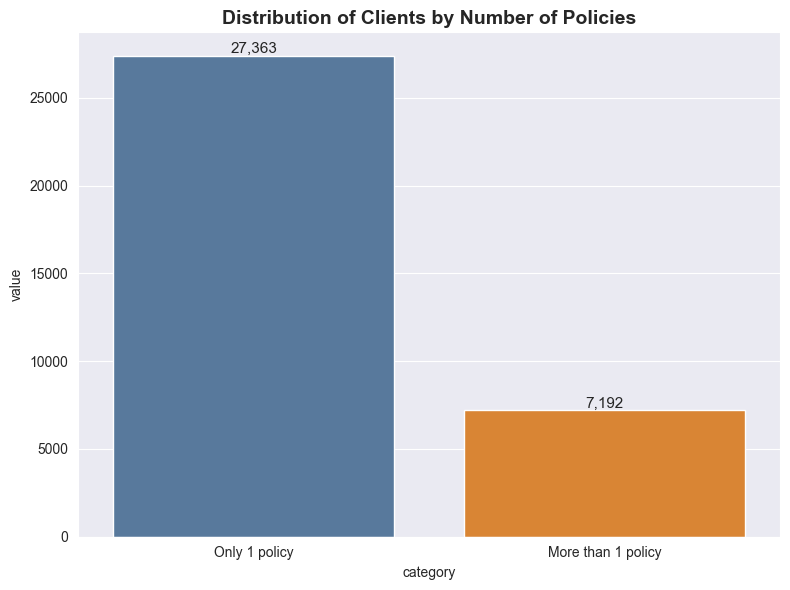

In [45]:
print('\n')
show_cli_policy_distribution(policy_client_data)
print('\n')

In [46]:
def normalize_by_group(values, group):
    values = np.asarray(values, dtype=float)
    out = np.zeros_like(values, dtype=float)

    start = 0
    for gsize in group:
        end = start + gsize
        x = values[start:end]

        x_min = np.min(x)
        x_max = np.max(x)

        if x_max > x_min:
            out[start:end] = (x - x_min) / (x_max - x_min)
        else:
            out[start:end] = 0.0

        start = end

    return out


def get_query_group(dataset):
    """
    Ranking grupa mora odgovarati jednoj ponudi/upitu.
    Ako postoji ponuda_id, to je sigurnije nego klijent_id + datum.
    """
    if "ponuda_id" in dataset.columns:
        return dataset.groupby("ponuda_id", sort=False).size().to_numpy()

    return dataset.groupby(["klijent_id", "dat_izdavanja"], sort=False).size().to_numpy()


def align_categorical_columns(X_train, X_val, categorical_cols):
    """
    Ne kodirati train i val kategorije odvojeno.
    Odvojeni .cat.codes moze napraviti bug:
    ista sifra u trainu i valu ne mora dobiti isti integer kod.
    """
    for col in categorical_cols:
        if col not in X_train.columns or col not in X_val.columns:
            continue


        train_vals = X_train[col].astype("object")
        val_vals = X_val[col].astype("object")

        categories = pd.Index(train_vals.dropna().unique()).union(
            pd.Index(val_vals.dropna().unique())
        )

        X_train[col] = pd.Categorical(train_vals, categories=categories).codes
        X_val[col] = pd.Categorical(val_vals, categories=categories).codes

    return X_train, X_val

In [47]:
# ============================================================
# GLAVNI PIPELINE
# ============================================================

if INCLUDE_RENEWAL_FEATURES:
    df = add_renewal_features(df)
else:
    df['days_since_same_type'] = -1
    df['likely_annual_renewal'] = -1
    df['likely_semi_renewal'] = -1
    df['days_since_same_type_missing'] = -1
    
if INCLUDE_SEASONAL_FEATURES:
    df = add_seasonal_features(df)
else:
    df['month']   = -1
    df['quarter'] = -1
    df['month_sin'] = -1
    df['month_cos'] = -1


# NOVO: KMeans klasteri - gradi se na cijelom df (demografija ne leakuje)
print("\n✅ Gradim KMeans klastere...")

num_of_kmeans_clusters = df['sif_vrsta'].nunique()

# Kandidati
all_types  = df['sif_vrsta'].unique()
candidates = pd.DataFrame({'candidate_type': all_types})
print(f"\nUnique policy types: {len(all_types)}")
print(f"Distribucija tipova polisa:\n{df['sif_vrsta'].value_counts(normalize=True).round(3)}")


DATE_COL = "dat_izdavanja"
CLIENT_COL = "klijent_id"

def build_fold_dataset(df_sorted, fold_spec, fold_name):
    
    cutoff = fold_spec["cutoff"]
    val_end = fold_spec["val_end"]

    train_df = df_sorted.loc[fold_spec["train_idx"]].copy()
    val_df = df_sorted.loc[fold_spec["val_idx"]].copy()

    print(f"\n--- BUILD {fold_name} ---")
    print(
        f"Train: {train_df[DATE_COL].min().date()} -> "
        f"{train_df[DATE_COL].max().date()} ({len(train_df):,})"
    )
    print(
        f"Val:   {val_df[DATE_COL].min().date()} -> "
        f"{val_df[DATE_COL].max().date()} ({len(val_df):,})"
    )

    train_dist = train_df["sif_vrsta"].value_counts(normalize=True)
    val_dist = val_df["sif_vrsta"].value_counts(normalize=True)
    dist_diff = (train_dist - val_dist).abs().mean()

    print(f"Distribucija train/val diff: {dist_diff:.4f}")

    # Lookup tablice se grade ISKLJUCIVO na train dijelu folda.
    markov_transitions = _build_markov_with_decay(train_df)
    mt_dict = markov_transitions.set_index(["from_type", "to_type"])["prob"].to_dict()

    global_pop, reg_pop = build_popularity_features(train_df)
    seg_markov_dict = build_segment_markov(train_df) if INCLUDE_SEGMENT_MARKOV else {}


    future_pairs_train = _build_future_pairs(train_df)
    future_pairs_val = _build_future_pairs(val_df)

    # Client clusters
    # NOVO — trimuj PRIJE nego gradimo cluster input features
    # Razlog: _build_cluster_input_data() pravi portfolio od sif_vrsta.
    # Zadnja polisa po klijentu je TARGET (ono što model treba predvidjeti).
    # Ako je ostavimo, portfolio uključuje "buduću" vrstu polise →
    # client_cluster feature u modelu indirektno nosi label informaciju.
    train_df_trimmed = train_df[train_df.groupby(CLIENT_COL).cumcount(ascending=False) != 0].copy()
    val_df_trimmed   = val_df[val_df.groupby(CLIENT_COL).cumcount(ascending=False) != 0].copy()
    
    if len(train_df_trimmed) < 100 or len(val_df_trimmed) < 20:
        raise ValueError(f"{fold_name}: premalo podataka nakon uklanjanja zadnje polise")

    if INCLUDE_CLIENT_CLUSTERS:
        cluster_map_train, kmeans_model, cluster_scaler, cluster_columns = build_client_train_clusters(
            train_df_trimmed,
            n_clusters=num_of_kmeans_clusters
        )
        
        cluster_map_val = apply_cluster_map_to_val(
            val_df_trimmed,
            kmeans_model,
            cluster_scaler,
            cluster_columns
        )
    else:
        cluster_map_train = {}
        cluster_map_val   = {}

    
    if USE_APRIORI_AS_FEATURE or BLEND_APRIORI:
        apriori_rules_for_chunks = build_apriori_rules(
            train_df_trimmed,
            min_support=APRIORI_MIN_SUPP,
            min_confidence=APRIORI_MIN_CONFIDENCE
        )
        rule_lookup_for_chunks = build_rule_lookup(apriori_rules_for_chunks)
    else:
        apriori_rules_for_chunks = None
        rule_lookup_for_chunks = {}

    
    # client_hist se i dalje gradi na PUNIM df-ovima jer koristi shift(1) — temporalno siguran
    client_hist_train = _build_client_history_matrix(train_df)
    
    client_hist_all = _build_client_history_matrix(
        pd.concat([train_df, val_df], ignore_index=True)
    )
    
    val_ponude      = set(val_df['ponuda_id'].unique())
    client_hist_val = client_hist_all[client_hist_all['ponuda_id'].isin(val_ponude)]
    
    history_type_cols = [c for c in client_hist_train.columns if c != "ponuda_id"]
    features = BASE_FEATURES + history_type_cols
    training_features = TRAINING_FEATURES + history_type_cols
    
    # Ovo sada postaje samo assignment (trim je već urađen iznad)
    train_df = train_df_trimmed
    val_df   = val_df_trimmed

    if len(train_df) < 100 or len(val_df) < 20:
        raise ValueError(f"{fold_name}: premalo podataka nakon uklanjanja zadnje polise")

    gc.collect()
    
    sc_train, td = _build_training_chunks(
        train_df, future_pairs_train, mt_dict, candidates,
        client_hist_train, global_pop, reg_pop, seg_markov_dict,
        cluster_map_train, features,
        chunks_dir=f"chunks_train_{fold_name}",
        rule_lookup=rule_lookup_for_chunks,   # ← bio apriori_rules=
    )
    
    sc_val, vd = _build_training_chunks(
        val_df, future_pairs_val, mt_dict, candidates,
        client_hist_val, global_pop, reg_pop, seg_markov_dict,
        cluster_map_val, features,
        chunks_dir=f"chunks_val_{fold_name}",
        rule_lookup=rule_lookup_for_chunks,   # ← isto
    )

    train_dataset = merge_chunks(sc_train, td)
    val_dataset = merge_chunks(sc_val, vd)

    # max_pg = len(all_types) * 7

    # train_dataset = cap_candidates(train_dataset, max_pg)
    # val_dataset = cap_candidates(val_dataset, max_pg)

    train_dataset = train_dataset.sort_values(
        [CLIENT_COL, DATE_COL]
    ).reset_index(drop=True)

    val_dataset = val_dataset.sort_values(
        [CLIENT_COL, DATE_COL]
    ).reset_index(drop=True)

    if DO_NEGATIVE_SAMPLING:
        # Negative sampling samo na trainu.
        train_dataset = sample_negatives(train_dataset)
        train_dataset = train_dataset.sort_values(
            [CLIENT_COL, DATE_COL]
        ).reset_index(drop=True)

    # drop_debug_features = ["target_is_renewal", "client_cluster"]
    drop_debug_features = ["target_is_renewal"]
    

    available_features = [
        c for c in training_features
        if c in train_dataset.columns and c in val_dataset.columns
        and c not in drop_debug_features
    ]
    
    print('\n\n')
    
    # Garancija — puca glasno ako debug feature uđe u model
    assert not any(f in available_features for f in DEBUG_FEATURES), \
        f"DEBUG_FEATURES su ušli u available_features: {set(DEBUG_FEATURES) & set(available_features)}"
    
    X_train = train_dataset[available_features].copy()
    X_val   = val_dataset[available_features].copy()


    
    X_train, X_val = align_categorical_columns(
        X_train,
        X_val,
        CATEGORICAL_FEATURES,
    )

    y_train = train_dataset["label"].astype(int).to_numpy()
    y_val = val_dataset["label"].astype(int).to_numpy()

    group_train = get_query_group(train_dataset)
    group_val = get_query_group(val_dataset)

    assert group_train.sum() == len(X_train)
    assert group_val.sum() == len(X_val)

    return {
        "fold": fold_spec["fold"],
        "fold_name": fold_name,
        "is_holdout": fold_spec["is_holdout"],
        "train_dataset": train_dataset,
        "val_dataset": val_dataset,
        "X_train": X_train,
        "X_val": X_val,
        "y_train": y_train,
        "y_val": y_val,
        "group_train": group_train,
        "group_val": group_val,
        "features": available_features,
        # APRIORI — ulazi u dict samo ako je uključen
        **( {"apriori_rules": apriori_rules_for_chunks} 
            if (BLEND_APRIORI or USE_APRIORI_AS_FEATURE) else {} )
    }



✅ Gradim KMeans klastere...

Unique policy types: 14
Distribucija tipova polisa:
sif_vrsta
1     0.349
6     0.204
7     0.161
8     0.074
5     0.071
9     0.048
15    0.038
13    0.018
22    0.018
17    0.007
23    0.004
12    0.003
4     0.003
11    0.002
Name: proportion, dtype: float64


In [48]:
def suggest_lgbm_params(trial):
    return {
        "objective": "lambdarank",
        "n_estimators": trial.suggest_int("n_estimators", 300, 1800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 96),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 120),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,
    }

In [49]:
def suggest_xgb_params(trial):
    return {
        'objective':        'rank:ndcg',
        'n_estimators':     trial.suggest_int('xgb_n_estimators', 200, 800),
        'learning_rate':    trial.suggest_float('xgb_learning_rate', 0.01, 0.15, log=True),
        'max_depth':        trial.suggest_int('xgb_max_depth', 3, 8),
        'min_child_weight': trial.suggest_int('xgb_min_child_weight', 5, 50),
        'subsample':        trial.suggest_float('xgb_subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('xgb_colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('xgb_reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda':       trial.suggest_float('xgb_reg_lambda', 1e-4, 5.0, log=True),
        'random_state':     42,
        'n_jobs':           -1,
        'verbosity':        0,
    }

In [50]:
def evaluate_ranker_scores(scores, y, group):
    return {
        "hr1": hit_rate_at_k(scores, y, group, k=1),
        "hr3": hit_rate_at_k(scores, y, group, k=3),
        "hr5": hit_rate_at_k(scores, y, group, k=5),
        "mrr5": mrr_at_k(scores, y, group, k=5),
        "ndcg5": ndcg_at_k(scores, y, group, k = 5)
    }

In [51]:
def optuna_objective(trial, fold_cache):

    lgbm_params = suggest_lgbm_params(trial)
    xgb_params  = suggest_xgb_params(trial)

    w_lgbm = trial.suggest_float('w_lgbm', 0.2, 0.7)
    w_xgb = trial.suggest_float('w_xgb', 0.2, 0.7)

    w_markov = (
        trial.suggest_float('w_markov', 0.05, 0.3)
        if BLEND_MARKOV_PROBS else 0.0
    )

    w_apriori = (
        trial.suggest_float('w_apriori', 0.05, 0.3)
        if BLEND_APRIORI else 0.0
    )

    total = w_lgbm + w_xgb + w_markov + w_apriori

    w_lgbm /= total
    w_xgb /= total
    w_markov /= total
    w_apriori /= total

    fold_scores = []

    for i, fd in enumerate(fold_cache):

        lgbm = LGBMRanker(**lgbm_params)
        lgbm.fit(
            fd['X_train'],
            fd['y_train'],
            group=fd['group_train'],
            eval_set=[(fd['X_val'], fd['y_val'])],
            eval_group=[fd['group_val']],
            # eval_at=[1, 3, 5],
            eval_at=[1],
            callbacks=[
                early_stopping(
                    stopping_rounds=80,
                    verbose=False,
                    first_metric_only=True  # <- KEY CHANGE
                )
            ]
        )

        xgb = XGBRanker(
            **xgb_params,
            early_stopping_rounds=50,
            # eval_metric="ndcg@1"  # <- KEY CHANGE
        )

        xgb.fit(
            fd['X_train'],
            fd['y_train'],
            group=fd['group_train'],
            eval_set=[(fd['X_val'], fd['y_val'])],
            eval_group=[fd['group_val']],
            verbose=False
        )

        lgbm_norm = normalize_by_group(
            lgbm.predict(fd['X_val']),
            fd['group_val']
        )

        xgb_norm = normalize_by_group(
            xgb.predict(fd['X_val']),
            fd['group_val']
        )

        markov_norm = (
            normalize_by_group(
                fd['val_dataset']['markov_prob'].values,
                fd['group_val']
            )
            if BLEND_MARKOV_PROBS
            else np.zeros(len(fd['y_val']))
        )

        # APRIORI
        if BLEND_APRIORI and 'apriori_rules' in fd:
            apriori_norm = normalize_by_group(
                fd['val_dataset']['candidate_apriori_score'].values, fd['group_val']
            )
        else:
            apriori_norm = np.zeros(len(fd['y_val']))

        blended = (
              w_lgbm   * lgbm_norm
            + w_xgb    * xgb_norm
            + w_markov * markov_norm
            + w_apriori * apriori_norm
        )

        metrics = evaluate_ranker_scores(
            blended,
            fd['y_val'],
            fd['group_val']
        )

        score = (
            HR3_WEIGHT * metrics['hr3']
            + MRR5_WEIGHT * metrics['mrr5']
        )

        fold_scores.append(score)

        trial.report(
            float(np.mean(fold_scores)),
            step=i
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

        del lgbm
        del xgb
        gc.collect()

    return float(np.mean(fold_scores))

In [52]:
def train_and_evaluate_best(lgbm_params, xgb_params, weights, fd, label):
    # weights je sada tuple od 4: (w_lgbm, w_xgb, w_markov, w_apriori)
    w_lgbm, w_xgb, w_markov, w_apriori = weights

    lgbm = LGBMRanker(**lgbm_params)
    lgbm.fit(
        fd['X_train'], fd['y_train'],
        group=fd['group_train'],
        eval_set=[(fd['X_val'], fd['y_val'])],
        eval_group=[fd['group_val']],
        eval_at=[1, 3],
        callbacks=[log_evaluation(50), early_stopping(100, verbose=False)]
    )

    xgb = XGBRanker(**xgb_params, eval_metric="ndcg@5", early_stopping_rounds=50)
    xgb.fit(
        fd['X_train'], fd['y_train'],
        group=fd['group_train'],
        eval_set=[(fd['X_val'], fd['y_val'])],
        eval_group=[fd['group_val']],
        verbose=50,
    )

    lgbm_norm   = normalize_by_group(lgbm.predict(fd['X_val']), fd['group_val'])
    xgb_norm    = normalize_by_group(xgb.predict(fd['X_val']),  fd['group_val'])
    markov_norm = normalize_by_group(
        fd['val_dataset']['markov_prob'].values, fd['group_val']
    ) if BLEND_MARKOV_PROBS else np.zeros(len(fd['y_val']))

    if BLEND_APRIORI and 'apriori_rules' in fd:
        apriori_norm = normalize_by_group(
            fd['val_dataset']['candidate_apriori_score'].values, fd['group_val']
        )
    else:
        apriori_norm = np.zeros(len(fd['y_val']))

    blended = (w_lgbm    * lgbm_norm
             + w_xgb     * xgb_norm
             + w_markov  * markov_norm
             + w_apriori * apriori_norm)

    metrics = evaluate_ranker_scores(blended, fd['y_val'], fd['group_val'])

    print(f"\n--- {label} ---")
    print(f"HR@1: {metrics['hr1']:.4f} | HR@3: {metrics['hr3']:.4f} | "
          f"HR@5: {metrics['hr5']:.4f} | MRR@5: {metrics['mrr5']:.4f} | NDCG@5: {metrics['ndcg5']:.4f}")
    print(f"Weights: LGBM={w_lgbm:.3f} XGB={w_xgb:.3f} "
          f"Markov={w_markov:.3f} Apriori={w_apriori:.3f}")

    return lgbm, xgb, blended, metrics

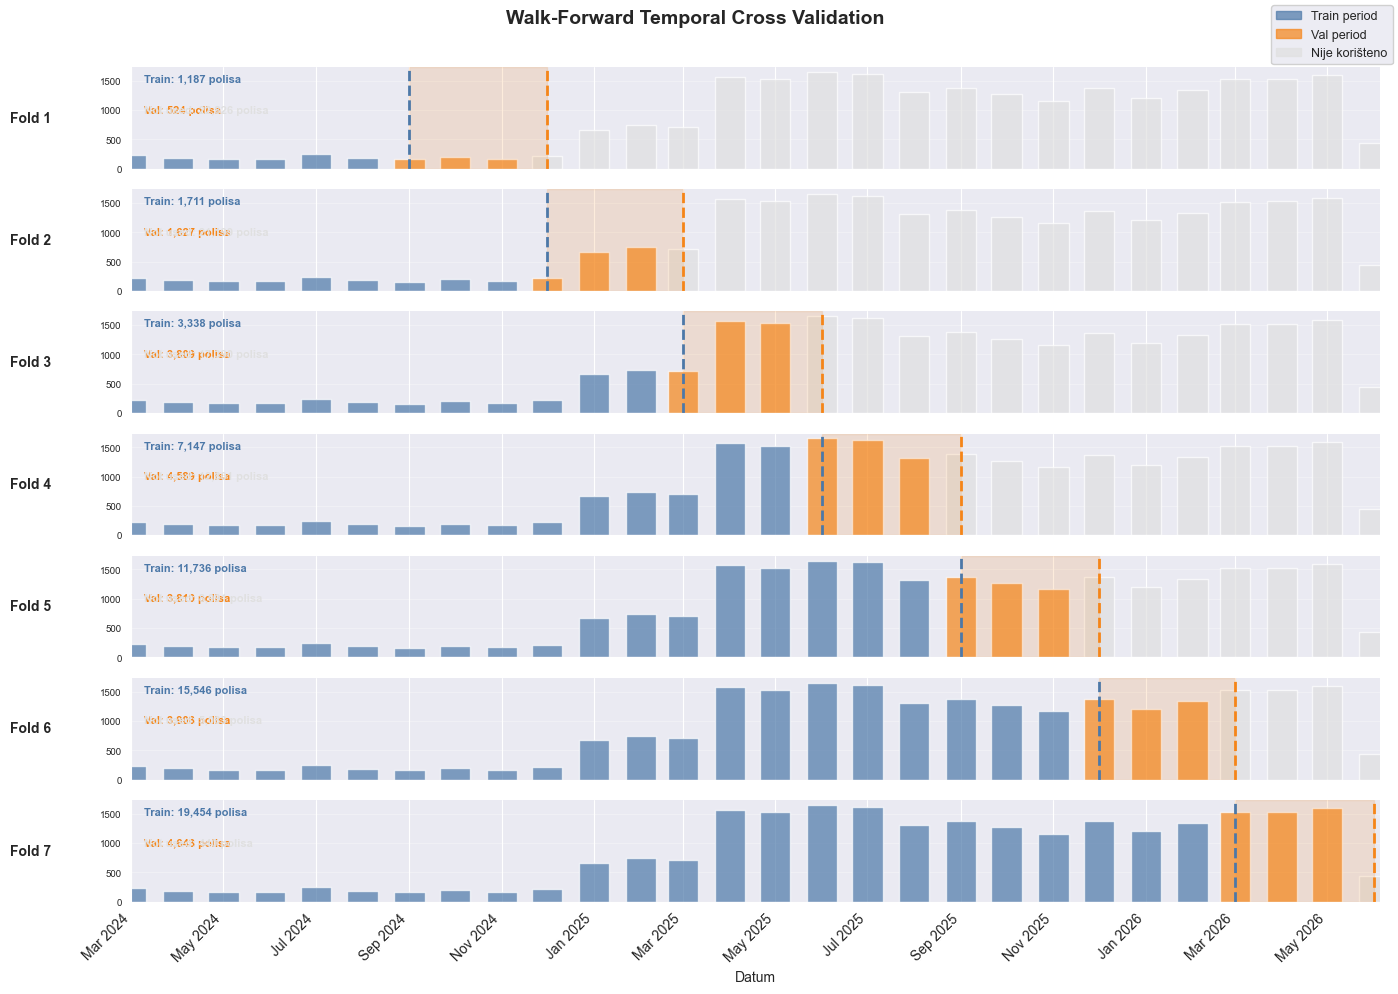


Fold   Train od     Train do     Val od       Val do         Train N    Val N  Dist diff
-------------------------------------------------------------------------------------
1      2024-03-01   2024-09-01   2024-09-01   2024-12-01       1,187      524     0.0064
2      2024-03-01   2024-12-01   2024-12-01   2025-03-01       1,711    1,627     0.3144
3      2024-03-01   2025-03-01   2025-03-01   2025-06-01       3,338    3,809     0.0632
4      2024-03-01   2025-06-01   2025-06-01   2025-09-01       7,147    4,589     0.0514
5      2024-03-01   2025-09-01   2025-09-01   2025-12-01      11,736    3,810     0.0258
6      2024-03-01   2025-12-01   2025-12-01   2026-03-01      15,546    3,908     0.0278
7      2024-03-01   2026-03-01   2026-03-01   2026-06-01      19,454    4,643     0.0302

Tražim optimalni broj KMeans klastera...

Referentni fold: fold 6 (9,107 redova nakon trim)
  k= 4: silhouette=0.1578  DB=1.6641  inertia=71565
  k= 5: silhouette=0.2028  DB=1.6731  inertia=68593
  k=

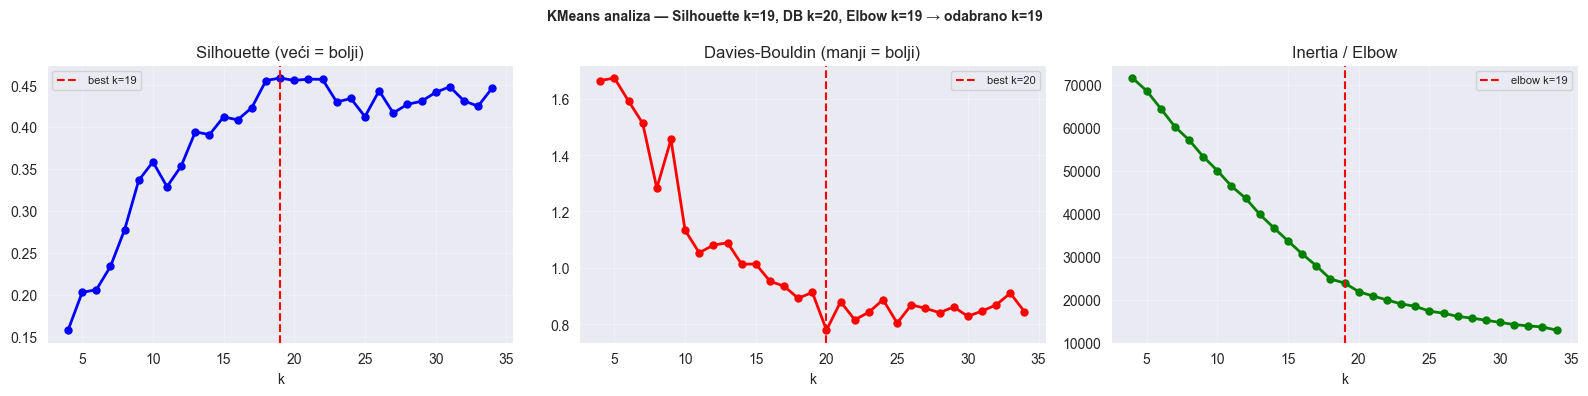


num_of_kmeans_clusters postavljen na: 19

--- BUILD f1 ---
Train: 2024-03-01 -> 2024-08-30 (1,187)
Val:   2024-09-02 -> 2024-11-29 (524)
Distribucija train/val diff: 0.0064
   Gradim 19 klijentskih klastera...
   Klasteri velicina: {0: 8, 1: 2, 2: 1, 3: 10, 4: 2, 5: 7, 6: 2, 7: 12, 8: 5, 9: 2, 10: 1, 11: 1, 12: 7, 13: 41, 14: 24, 15: 1, 16: 4, 17: 2, 18: 3}


chunks_val_f1: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.70it/s]


   Shape: (8918, 44)
   Shape: (3360, 44)




--- BUILD f2 ---
Train: 2024-03-01 -> 2024-11-29 (1,711)
Val:   2024-12-02 -> 2025-02-28 (1,627)
Distribucija train/val diff: 0.3144
   Gradim 19 klijentskih klastera...
   Klasteri velicina: {0: 14, 1: 10, 2: 9, 3: 2, 4: 8, 5: 35, 6: 2, 7: 6, 8: 49, 9: 3, 10: 1, 11: 9, 12: 1, 13: 3, 14: 1, 15: 9, 16: 5, 17: 6, 18: 2}


chunks_val_f2: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.32it/s]


   Shape: (13398, 44)
   Shape: (7658, 44)




--- BUILD f3 ---
Train: 2024-03-01 -> 2025-02-28 (3,338)
Val:   2025-03-01 -> 2025-05-31 (3,809)
Distribucija train/val diff: 0.0632
   Gradim 19 klijentskih klastera...
   Klasteri velicina: {0: 100, 1: 1, 2: 61, 3: 5, 4: 43, 5: 18, 6: 30, 7: 9, 8: 8, 9: 7, 10: 29, 11: 42, 12: 1, 13: 2, 14: 6, 15: 17, 16: 1, 17: 3, 18: 18}


...

C:\Users\Korisnik\Desktop\wienner ml client-polisa predictions\venv\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
C:\Users\Korisnik\Desktop\wienner ml client-polisa predictions\venv\lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/75 [00:00<?, ?it/s]


BEST OPTUNA SCORE: 0.7381119957472002
BEST PARAMS:
{'n_estimators': 1145, 'learning_rate': 0.04562008343716946, 'num_leaves': 23, 'max_depth': 3, 'min_child_samples': 96, 'subsample': 0.7786401838510367, 'colsample_bytree': 0.7918292745720442, 'reg_alpha': 0.0007098165483699864, 'reg_lambda': 0.011750969842721577, 'min_split_gain': 0.7453418447302073, 'xgb_n_estimators': 372, 'xgb_learning_rate': 0.024313594003904492, 'xgb_max_depth': 7, 'xgb_min_child_weight': 22, 'xgb_subsample': 0.7372326158693723, 'xgb_colsample_bytree': 0.679408042522845, 'xgb_reg_alpha': 0.5248787693743087, 'xgb_reg_lambda': 4.659601760094003, 'w_lgbm': 0.4979136826215109, 'w_xgb': 0.28450600036915885}
[50]	valid_0's ndcg@1: 1	valid_0's ndcg@3: 1
[100]	valid_0's ndcg@1: 1	valid_0's ndcg@3: 1
[0]	validation_0-ndcg@5:0.99583
[50]	validation_0-ndcg@5:1.00000
[52]	validation_0-ndcg@5:1.00000

--- BEST MODEL CV Fold 1 ---
HR@1: 0.9417 | HR@3: 0.9417 | HR@5: 0.9417 | MRR@5: 0.9417 | NDCG@5: 1.0000
Weights: LGBM=0.636 

chunks_val_holdout_f7: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.06s/it]


   Shape: (175280, 56)
   Shape: (24038, 56)



[50]	valid_0's ndcg@1: 0.698893	valid_0's ndcg@3: 0.834702
[100]	valid_0's ndcg@1: 0.700641	valid_0's ndcg@3: 0.834245
[150]	valid_0's ndcg@1: 0.697729	valid_0's ndcg@3: 0.831347
[0]	validation_0-ndcg@5:0.83786
[50]	validation_0-ndcg@5:0.86174
[100]	validation_0-ndcg@5:0.86170
[140]	validation_0-ndcg@5:0.86166

--- FINAL TEMPORAL HOLDOUT ---
HR@1: 0.6209 | HR@3: 0.8451 | HR@5: 0.8946 | MRR@5: 0.7346 | NDCG@5: 0.8451
Weights: LGBM=0.636 XGB=0.364 Markov=0.000 Apriori=0.000


In [53]:
df_sorted, folds = make_temporal_folds(
    df,
    val_months=3,
    min_train_months=6,
    step_months=3,
    reserve_last_fold=True,
)

cv_folds      = [f for f in folds if not f['is_holdout']]
holdout_folds = [f for f in folds if f['is_holdout']]

# ============================================================
# OPTIMALNI BROJ KLASTERA — jednom, prije fold buildanja
# ============================================================
if INCLUDE_CLIENT_CLUSTERS:
    print("\nTražim optimalni broj KMeans klastera...")

    ref_fold_spec = sorted(cv_folds, key=lambda f: len(f['train_idx']), reverse=True)[0]
    ref_train     = df_sorted.loc[ref_fold_spec['train_idx']].copy()
    ref_trimmed   = ref_train[
        ref_train.groupby(CLIENT_COL).cumcount(ascending=False) != 0
    ].copy()
    print(f"\nReferentni fold: fold {ref_fold_spec['fold']} ({len(ref_trimmed):,} redova nakon trim)")

    cluster_input = _build_cluster_input_data(ref_trimmed)
    scaler_tmp    = StandardScaler()
    X_scaled      = scaler_tmp.fit_transform(cluster_input)

    silhouette_scores     = []
    davies_bouldin_scores = []
    inertias              = []
    K_range               = range(4, 35)

    for k in K_range:
        km     = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        silhouette_scores.append(
            silhouette_score(X_scaled, labels, sample_size=min(2000, len(X_scaled)))
        )
        davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
        inertias.append(km.inertia_)
        print(
            f"  k={k:2d}: silhouette={silhouette_scores[-1]:.4f}"
            f"  DB={davies_bouldin_scores[-1]:.4f}"
            f"  inertia={inertias[-1]:.0f}"
        )

    # Vizualizacija
    # Vizualizacija + oznake u jednom prolasku
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    best_k_silhouette = list(K_range)[np.argmax(silhouette_scores)]
    best_k_db         = list(K_range)[np.argmin(davies_bouldin_scores)]

    inertia_arr  = np.array(inertias)
    second_deriv = np.diff(np.diff(inertia_arr))
    best_k_elbow = list(K_range)[np.argmax(second_deriv) + 2]

    # Silhouette
    axes[0].plot(list(K_range), silhouette_scores, 'bo-', linewidth=2, markersize=5)
    axes[0].axvline(best_k_silhouette, color='red', linestyle='--', label=f'best k={best_k_silhouette}')
    axes[0].set_title('Silhouette (veći = bolji)')
    axes[0].set_xlabel('k')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    # Davies-Bouldin
    axes[1].plot(list(K_range), davies_bouldin_scores, 'ro-', linewidth=2, markersize=5)
    axes[1].axvline(best_k_db, color='red', linestyle='--', label=f'best k={best_k_db}')
    axes[1].set_title('Davies-Bouldin (manji = bolji)')
    axes[1].set_xlabel('k')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    # Elbow
    axes[2].plot(list(K_range), inertias, 'go-', linewidth=2, markersize=5)
    axes[2].axvline(best_k_elbow, color='red', linestyle='--', label=f'elbow k={best_k_elbow}')
    axes[2].set_title('Inertia / Elbow')
    axes[2].set_xlabel('k')
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.3)

    print(f"\nPrijedlozi:")
    print(f"  Silhouette     → k={best_k_silhouette}")
    print(f"  Davies-Bouldin → k={best_k_db}")
    print(f"  Elbow          → k={best_k_elbow}")

    # Kada se metrike previše razlikuju (raspon > 10), osloni se na elbow
    # Elbow je najkonzervativniji i ne overfittuje broj klastera
    spread = max(best_k_silhouette, best_k_db, best_k_elbow) - \
             min(best_k_silhouette, best_k_db, best_k_elbow)

    if spread <= 5:
        best_k = int(np.median([best_k_silhouette, best_k_db, best_k_elbow]))
        print(f"  → Metrike konzistentne (raspon={spread}), medijana: k={best_k}")
    elif spread <= 10:
        best_k = int(np.median([best_k_silhouette, best_k_db, best_k_elbow]))
        print(f"  → Metrike umjereno konzistentne (raspon={spread}), medijana: k={best_k}")
        print(f"     ⚠️  Razmotri ručni odabir na osnovu grafova.")
    else:
        best_k = best_k_elbow
        print(f"  → Metrike jako divergiraju (raspon={spread}), koristim elbow: k={best_k}")
        print(f"     ⚠️  Podaci vjerovatno nemaju jasnu klaster strukturu.")
        print(f"     ⚠️  Razmotri INCLUDE_CLIENT_CLUSTERS=False i testiraj holdout bez klastera.")

    fig.suptitle(
        f'KMeans analiza — Silhouette k={best_k_silhouette}, '
        f'DB k={best_k_db}, Elbow k={best_k_elbow} → odabrano k={best_k}',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    num_of_kmeans_clusters = best_k
    print(f"\nnum_of_kmeans_clusters postavljen na: {num_of_kmeans_clusters}")

    del ref_train, ref_trimmed, cluster_input, scaler_tmp, X_scaled
    gc.collect()

# ============================================================
# 1. Build CV foldova
# ============================================================
fold_cache = []

for f in cv_folds:
    fd = build_fold_dataset(df_sorted, f, f'f{f["fold"]}')
    fold_cache.append(fd)

# 2. Filtriraj premale foldove
# NOVO — dva filtera:
# 1. MIN_VAL_GROUPS >= 300: statički premali val setovi daju nestabilne metrike
#    (fold 1 ima 151 grupu → CI ±7%, nije pouzdan signal za Optunu)
# 2. MAX_DIST_DIFF <= 0.10: ako je distribucija tipova polisa drastično drugačija
#    u val periodu, metrika ne mjeri pravu generalizaciju
#    (fold 2 ima dist_diff=0.3144 → 5x veći od ostalih, outlier)
MIN_VAL_GROUPS = 300
MAX_DIST_DIFF  = 0.10

cv_folds_for_optuna = []

for fd in fold_cache:
    n_val_groups = fd['val_dataset'].groupby(
        ['klijent_id', 'dat_izdavanja']
    ).ngroups

    val_df_tmp   = fd['val_dataset']
    train_df_tmp = fd['train_dataset']
    td = train_df_tmp['sif_vrsta'].value_counts(normalize=True)
    vd = val_df_tmp['sif_vrsta'].value_counts(normalize=True)
    dist_diff = (td - vd).abs().mean()

    reason = []
    if n_val_groups < MIN_VAL_GROUPS:
        reason.append(f"premalo val grupa ({n_val_groups} < {MIN_VAL_GROUPS})")
    if dist_diff > MAX_DIST_DIFF:
        reason.append(f"dist_diff prevelik ({dist_diff:.4f} > {MAX_DIST_DIFF})")

    if reason:
        print(f"Fold {fd['fold']}: ISKLJUČEN — {', '.join(reason)}")
    else:
        print(f"Fold {fd['fold']}: {n_val_groups} val grupa, dist_diff={dist_diff:.4f} ✓")
        cv_folds_for_optuna.append(fd)


print(f"\nFoldovi za Optuna: {len(cv_folds_for_optuna)} "
      f"(isključeno {len(fold_cache) - len(cv_folds_for_optuna)})")

# 3. Optuna - jedan poziv
# Sampler odlučuje: koje hyperparametre ću probati sljedeće
# TPESampler(multivariate=True, group=True)
# TPE (Tree-structured Parzen Estimator) → ne random
# uči iz prethodnih trialova
# pokušava pogoditi “dobre regije parametara”
# multivariate=True  | ne optimizira svaki parametar izolovano nego gleda kombinacije
# group=True | gleda strukturu trialova kao grupu korisno za ranking / fold evaluacije
# PRUNER = KADA PREKINUTI LOŠ TRIAL
# pruner odlučuje: da li da ubijem ovaj trial prije nego što završi
# n_startup_trials=10 prvih 10 trialova ne pruni (da se sakupi “baseline”)
# n_warmup_steps=1 ne pruni odmah na početku jednog triala (da se model bar malo “razvije”) | u svakom trial-u, prve evaluacijske tačke se ne prunaju
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True, group=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1),
)

study.optimize(
    lambda trial: optuna_objective(trial, cv_folds_for_optuna),
    n_trials=OPTUNA_NTRIALS,
    show_progress_bar=True,
)

print("\nBEST OPTUNA SCORE:", study.best_value)
print("BEST PARAMS:")
print(study.best_params)

# 4. Evaluacija na svim CV foldovima sa najboljim parametrima
best_params = suggest_lgbm_params(optuna.trial.FixedTrial(study.best_params))
# Izvuci weightove i normaliziraj
w_lgbm   = study.best_params['w_lgbm']
w_xgb    = study.best_params['w_xgb']
w_markov = study.best_params.get('w_markov', 0.0)
w_apriori = study.best_params.get('w_apriori', 0.0)

total    = w_lgbm + w_xgb + w_markov + w_apriori
weights  = (w_lgbm/total, w_xgb/total, w_markov/total, w_apriori/total)

lgbm_params = suggest_lgbm_params(optuna.trial.FixedTrial(study.best_params))
xgb_params  = suggest_xgb_params(optuna.trial.FixedTrial(study.best_params))

# 4. Evaluacija na svim CV foldovima
cv_results = []

for fd in fold_cache:
    
    lgbm_m, xgb_m, preds, metrics = train_and_evaluate_best(
        lgbm_params, xgb_params, weights,
        fd, label=f"BEST MODEL CV Fold {fd['fold']}"
    )
    
    cv_results.append({"fold": fd["fold"], **metrics})


cv_df = pd.DataFrame(cv_results)
print("\nCV SUMMARY")
print(cv_df.round(4).to_string(index=False))

cv_df_clean = cv_df[cv_df['fold'] > 1]
print("Mean (bez Fold 1):"); print(cv_df_clean[["hr1","hr3","hr5","mrr5"]].mean().round(4))
print("Std (bez Fold 1):");  print(cv_df_clean[["hr1","hr3","hr5","mrr5"]].std().round(4))

realistic_folds = cv_df[cv_df['fold'] > 1]
print("\nRealni CV (bez Fold 1 - premali val set):")
print(f"HR@1: {realistic_folds['hr1'].mean():.4f} ± {realistic_folds['hr1'].std():.4f}")
print(f"HR@3: {realistic_folds['hr3'].mean():.4f} ± {realistic_folds['hr3'].std():.4f}")
print(f"HR@5: {realistic_folds['hr5'].mean():.4f} ± {realistic_folds['hr5'].std():.4f}")

# 5. Holdout
if holdout_folds:
    
    holdout_fd = build_fold_dataset(
        df_sorted, holdout_folds[0], f'holdout_f{holdout_folds[0]["fold"]}'
    )
    
    lgbm_model, xgb_model, holdout_preds, holdout_metrics = train_and_evaluate_best(
        lgbm_params, xgb_params, weights,
        holdout_fd, label="FINAL TEMPORAL HOLDOUT"
    )

In [54]:
import joblib
joblib.dump(lgbm_model, 'lgbm_ranker_v7.pkl')
joblib.dump(xgb_model, 'xgb_ranker_v7.pkl')

['xgb_ranker_v7.pkl']

In [55]:
def plot_rank_distribution(preds_all, y_all, group, title="Rank distribucija label=1"):
    
    ranks = []
    start = 0
    
    for g in group:
        
        end = start + g
        preds = preds_all[start:end]
        labels = y_all[start:end]
        
        # Sortiraj od najveće predikcije prema najmanjoj (rank 1 = najvjerovatnije)
        sorted_idx = np.argsort(-preds)
        for rank, idx in enumerate(sorted_idx, 1):
            if labels[idx] == 1:
                ranks.append(rank)
                break  # samo jedan label=1 po grupi
        
        start = end
    
    ranks = np.array(ranks)
    n_groups = len(ranks)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    
    # Histogram rangova
    max_rank = min(ranks.max(), 14)  # broj policy tipova

    max_rank = policy_client_data['sif_vrsta'].nunique()
    
    axes[0].hist(ranks, bins=range(1, max_rank + 2), align='left', 
                 color='#4C78A8', edgecolor='white', rwidth=0.85)
    axes[0].set_xlabel('Rank label=1')
    axes[0].set_ylabel('Broj query-a')
    axes[0].set_title('Distribucija ranka')
    axes[0].set_xticks(range(1, max_rank + 1))
    
    # Kumulativna kriva (= HR@K za svaki K)
    k_values = range(1, max_rank + 1)
    hr_at_k  = [np.mean(ranks <= k) for k in k_values]
    axes[1].plot(k_values, hr_at_k, 'o-', color='#F58518', linewidth=2, markersize=6)
    axes[1].axhline(y=hr_at_k[0], color='#4C78A8', linestyle='--', alpha=0.5, label=f'HR@1={hr_at_k[0]:.3f}')
    axes[1].axhline(y=hr_at_k[2], color='#1D9E75', linestyle='--', alpha=0.5, label=f'HR@3={hr_at_k[2]:.3f}')
    axes[1].axhline(y=hr_at_k[4], color='#E45756', linestyle='--', alpha=0.5, label=f'HR@5={hr_at_k[4]:.3f}')
    axes[1].set_xlabel('K')
    axes[1].set_ylabel('Hit Rate@K')
    axes[1].set_title('Kumulativni HR@K')
    axes[1].set_xticks(list(k_values))
    axes[1].set_ylim(0, 1.05)
    axes[1].legend(fontsize=9)
    axes[1].grid(axis='y', alpha=0.3)
    
    # Statistike ispod
    print(f"\nRank statistike ({n_groups} query-a):")
    print(f"  Rank 1 (HR@1): {np.mean(ranks == 1):.3f} ({np.sum(ranks == 1)} query-a)")
    print(f"  Rank 2:        {np.mean(ranks == 2):.3f}")
    print(f"  Rank 3:        {np.mean(ranks == 3):.3f}")
    print(f"  Rank >5:       {np.mean(ranks > 5):.3f} ({np.sum(ranks > 5)} query-a)")
    print(f"  Median rank:   {np.median(ranks):.1f}")
    print(f"  Mean rank:     {np.mean(ranks):.2f}")
    
    plt.tight_layout()
    plt.show()
    
    return ranks


Rank statistike (1575 query-a):
  Rank 1 (HR@1): 0.677 (1066 query-a)
  Rank 2:        0.179
  Rank 3:        0.065
  Rank >5:       0.025 (39 query-a)
  Median rank:   1.0
  Mean rank:     1.63


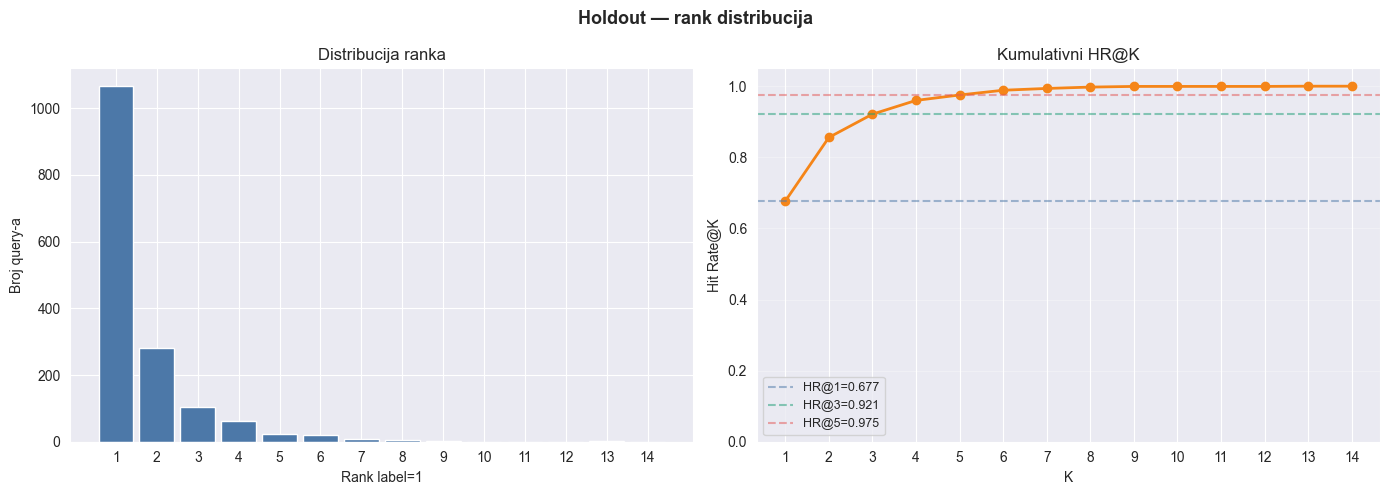

In [56]:
holdout_ranks = plot_rank_distribution(
    holdout_preds, 
    holdout_fd['y_val'], 
    holdout_fd['group_val'],
    title="Holdout — rank distribucija"
)

In [57]:
# lgbm_preds = lgbm_m.predict(fd['X_val'])
# # ... blend ako hoćeš blended preds
# plot_rank_distribution(blended_preds, fd['y_val'], fd['group_val'], title=f"Fold {fd['fold']}")

In [58]:
print(policy_client_data['sif_vrsta'].unique())

[ 6 12  1  8  7 15 17  5  9 13 11 23 22  4]


In [59]:
policy_client_data[policy_client_data['sif_vrsta'] > 11]

,ponuda_id,sif_vrsta,sif_org_jed,dat_od_ug,dat_do_ug,dat_izdavanja,sif_nac_plac,br_rata,premija_ukupno,ind_user_skadenca,suma_osiguranja,uw_indikator,konacna_premija,ind_dug,ind_steta,godina,days_old,years_old,osig_kanton_y,osig_opstina_y,klijent_id,is_foreign,ownerType,age,birth_place,gender,merrige_status,age_bucket,driving_experience,sif_uloga,has_prev_policy
156,521,12,507,2024-04-21,2025-04-21,2024-04-10,1.0,12.0,4233.06,0,6000.0,0,NaN,1,1,2024,793,2.171116,99.0,74.0,280,0,0,NaN,NaN,NaN,1.0,NaN,6.0,11,1
279,12,12,487,2024-03-01,2025-03-01,2024-03-11,1.0,1.0,1846.80,0,6000.0,0,NaN,0,0,2024,823,2.253251,99.0,74.0,10,0,0,NaN,NaN,NaN,1.0,NaN,6.0,11,1
373,999,12,467,2024-04-14,2025-04-14,2024-04-08,1.0,4.0,534.60,0,6000.0,0,NaN,0,0,2024,795,2.176591,7.0,180.0,500,0,0,NaN,NaN,NaN,1.0,NaN,6.0,11,1
428,1373,12,487,2024-05-07,2025-05-07,2024-04-26,1.0,12.0,933.12,0,6000.0,0,NaN,1,0,2024,777,2.127310,99.0,74.0,755,0,0,NaN,NaN,NaN,1.0,NaN,6.0,11,1
469,1119,12,487,2024-04-23,2025-04-23,2024-04-19,1.0,1.0,1312.20,0,4000.0,0,NaN,0,1,2024,784,2.146475,99.0,74.0,609,0,0,NaN,NaN,NaN,1.0,NaN,6.0,11,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64978,133758,15,164,2026-06-07,2033-06-07,2026-06-04,0.0,0.0,457.60,1,26000.0,0,0.0,0,0,2026,8,0.021903,1.0,3.0,68724,0,1,28.0,11,0.0,1.0,1,6.0,13,0
64998,133762,15,164,2026-06-03,2036-06-03,2026-06-04,0.0,0.0,1330.00,1,50000.0,0,0.0,0,0,2026,8,0.021903,1.0,97.0,50065,0,1,20.0,11,0.0,1.0,0,2.0,13,0
65004,133764,15,164,2026-06-03,2033-06-03,2026-06-04,0.0,0.0,475.20,1,27000.0,0,0.0,0,0,2026,8,0.021903,1.0,3.0,68730,0,1,31.0,11,1.0,1.0,1,6.0,13,0
65036,133918,15,159,2026-06-04,2031-06-04,2026-06-05,0.0,1.0,693.00,1,21000.0,0,NaN,0,0,2026,7,0.019165,1.0,3.0,68787,0,1,52.0,11,1.0,0.0,3,12.0,13,0


Skippovano (bez label=1): 142
is_predicted suma: 1575
label suma:        1575


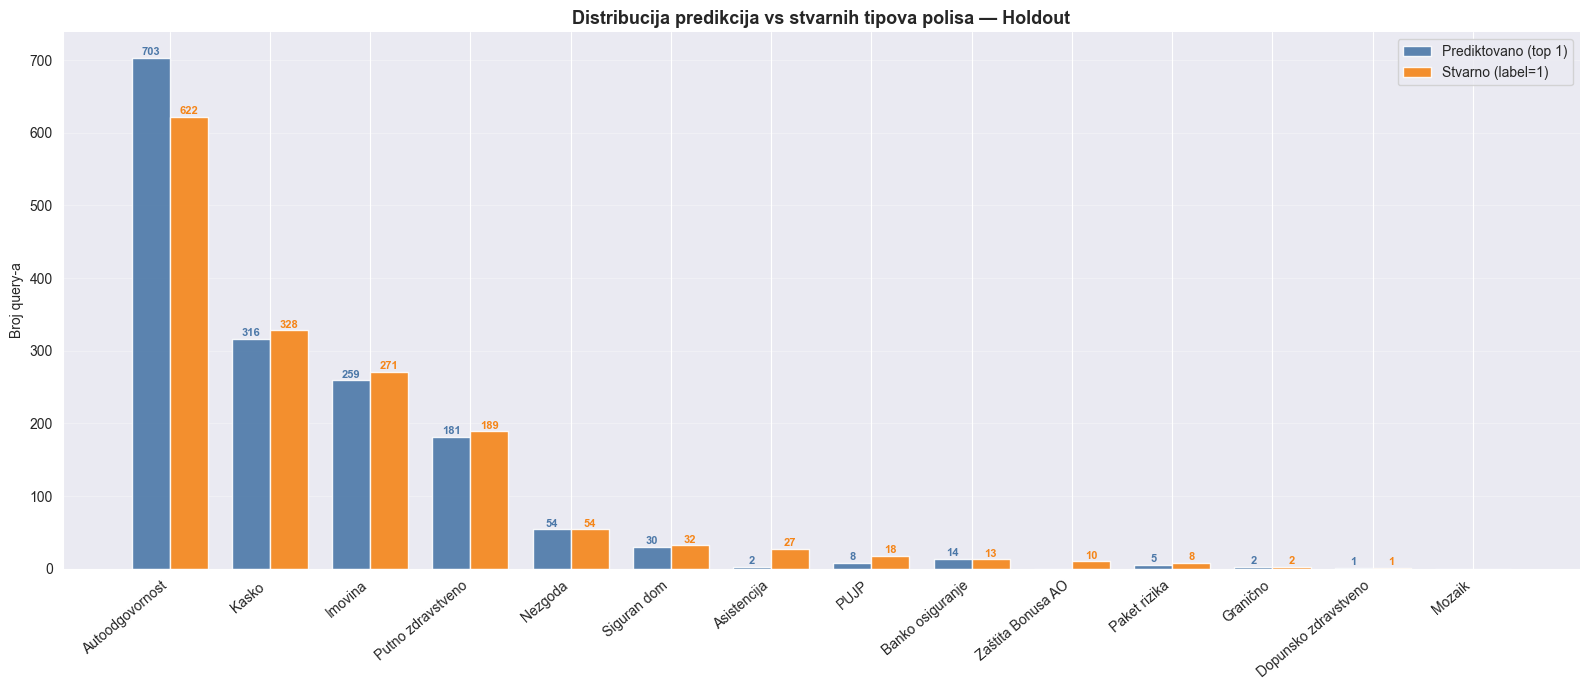

In [60]:
# ============================================================
# DISTRIBUCIJA PREDIKCIJA VS STVARNIH PO TIPU POLISE
# ============================================================

val_ds_predictions = holdout_fd['val_dataset'][['ponuda_id', 'candidate_type', 'label']].copy()
val_ds_predictions['model_predictions'] = holdout_preds
val_ds_predictions['is_predicted'] = 0

start = 0
skipped = 0
for g in holdout_fd['group_val']:
    end = start + g
    labels_slice = val_ds_predictions.iloc[start:end]['label'].values
    
    if labels_slice.sum() == 0:
        skipped += 1
        start = end
        continue
    
    top1_iloc = val_ds_predictions.iloc[start:end]['model_predictions'].values.argmax()
    val_ds_predictions.iloc[start + top1_iloc, val_ds_predictions.columns.get_loc('is_predicted')] = 1
    start = end

print(f"Skippovano (bez label=1): {skipped}")
print(f"is_predicted suma: {val_ds_predictions['is_predicted'].sum()}")  # sada 1575
print(f"label suma:        {val_ds_predictions['label'].sum()}")   

# Mapiranje sif_vrsta -> ime
policy_type_map = (
    policy_types[
        (policy_types['ind_polisa'] == 'D') &
        (policy_types['sif_vrsta'].isin(val_ds_predictions['candidate_type'].unique()))
    ]
    .set_index('sif_vrsta')['opis']
    .to_dict()
)

pred_label_dist = (
    val_ds_predictions
    .groupby('candidate_type')[['label', 'is_predicted']]
    .sum()
    .reset_index()
)
pred_label_dist['type'] = pred_label_dist['candidate_type'].map(policy_type_map).fillna(pred_label_dist['candidate_type'].astype(str))
pred_label_dist = pred_label_dist.sort_values('label', ascending=False)

# ============================================================
# PLOT — stacked bar
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(pred_label_dist))
width = 0.38

bars_pred   = ax.bar(x - width/2, pred_label_dist['is_predicted'], width,
                     label='Prediktovano (top 1)', color='#4C78A8', alpha=0.9)
bars_actual = ax.bar(x + width/2, pred_label_dist['label'],        width,
                     label='Stvarno (label=1)',    color='#F58518', alpha=0.9)

for bar in bars_pred:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=8, color='#4C78A8', fontweight='bold')

for bar in bars_actual:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(int(h)),
                ha='center', va='bottom', fontsize=8, color='#F58518', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(pred_label_dist['type'], rotation=40, ha='right', fontsize=10)
ax.set_ylabel('Broj query-a')
ax.set_title('Distribucija predikcija vs stvarnih tipova polisa — Holdout', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [61]:
# Koliko redova ima nenulti apriori score
print(f"Nenulti apriori score: {(holdout_fd['val_dataset']['candidate_apriori_score'] > 0).sum()}")
print(f"Ukupno redova: {len(holdout_fd['val_dataset'])}")
print(f"Postotak nenultih: {(holdout_fd['val_dataset']['candidate_apriori_score'] > 0).mean():.3f}")

print(f"\nDistribucija apriori score-a:")
print(holdout_fd['val_dataset']['candidate_apriori_score'].describe())

print(f"\nKoliko unique vrijednosti:")
print(holdout_fd['val_dataset']['candidate_apriori_score'].nunique())

# Koliko klijenata ima ikakav apriori signal
has_signal = holdout_fd['val_dataset'].groupby('klijent_id')['candidate_apriori_score'].max()
print(f"\nKlijenata sa bar jednim nenultim score-om: {(has_signal > 0).sum()} od {len(has_signal)}")

Nenulti apriori score: 2837
Ukupno redova: 24038
Postotak nenultih: 0.118

Distribucija apriori score-a:
count    24038.000000
mean         0.031174
std          0.112884
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.877064
Name: candidate_apriori_score, dtype: float64

Koliko unique vrijednosti:
17

Klijenata sa bar jednim nenultim score-om: 494 od 754


In [62]:
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(holdout_fd['X_val'])

# global importance
shap_importance = pd.DataFrame({
    'feature': holdout_fd['X_val'].columns,
    'importance': abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print(shap_importance.head(20))

                        feature  importance
25          segment_markov_prob    1.230191
24                  markov_prob    0.270966
29       candidate_regional_pop    0.193522
4                candidate_type    0.021000
3        days_since_last_policy    0.017132
27      candidate_apriori_score    0.013279
5     candidate_same_as_current    0.011634
2               cnt_type_before    0.007571
30         days_since_same_type    0.006972
11       avg_insurance_sum_past    0.006075
10             avg_premium_past    0.005613
28         candidate_global_pop    0.004856
12        avg_premium_since_now    0.004356
40                       type_6    0.004292
14                          age    0.002643
26               client_cluster    0.002123
0             n_policies_before    0.002053
13  avg_insurance_sum_since_now    0.001436
49                      type_22    0.000601
50                      type_23    0.000484


In [67]:
# Uzmi samo uzorak da ne traje 42 minute
sample_size = 2000
idx = np.random.choice(len(holdout_fd['X_val']), sample_size, replace=False)
X_sample = holdout_fd['X_val'].iloc[idx]

explainer   = shap.Explainer(xgb_model.predict, X_sample)
shap_values = explainer(X_sample)

shap_importance = pd.DataFrame({
    'feature'   : holdout_fd['X_val'].columns,
    'importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values('importance', ascending=False)

print(shap_importance.head(20))

PermutationExplainer explainer: 2001it [03:15,  9.71it/s]                                                                                                           


                      feature  importance
25        segment_markov_prob    0.393780
24                markov_prob    0.111878
29     candidate_regional_pop    0.058830
4              candidate_type    0.018101
30       days_since_same_type    0.016820
5   candidate_same_as_current    0.014306
28       candidate_global_pop    0.013782
14                        age    0.011280
50                    type_23    0.008235
12      avg_premium_since_now    0.008166
40                     type_6    0.008149
2             cnt_type_before    0.007947
0           n_policies_before    0.005694
37                     type_1    0.005672
11     avg_insurance_sum_past    0.005311
3      days_since_last_policy    0.005024
27    candidate_apriori_score    0.004796
10           avg_premium_past    0.004155
26             client_cluster    0.003572
39                     type_5    0.002848


C:\Users\Korisnik\AppData\Local\Temp\ipykernel_10368\2392089428.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, holdout_fd['X_val'], plot_type="bar")


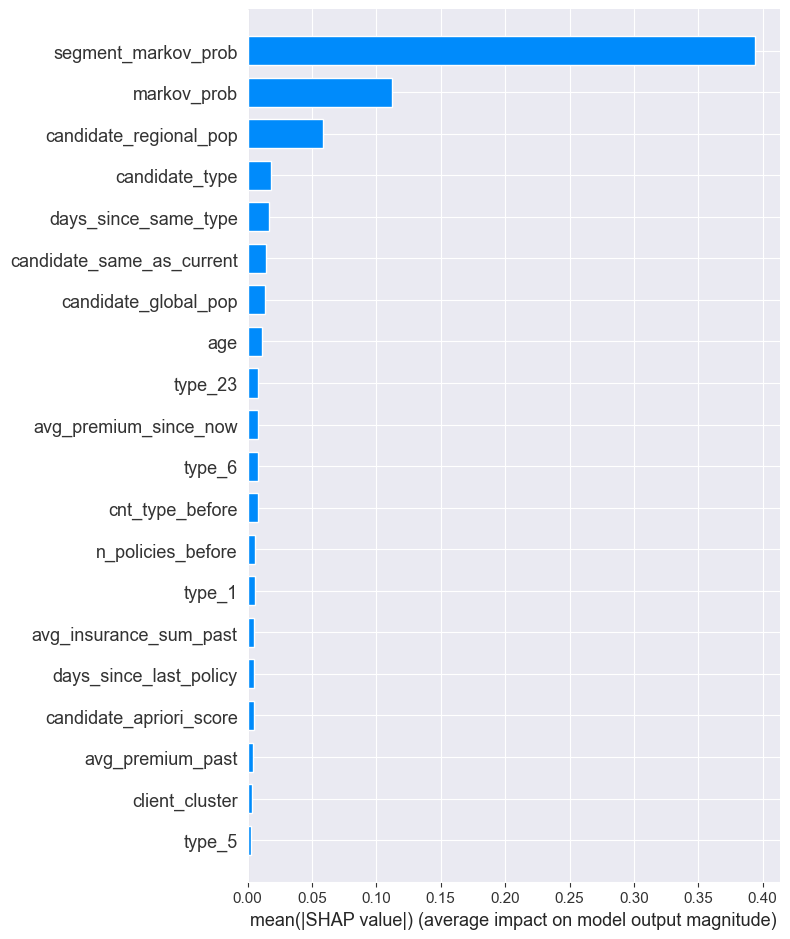

In [68]:
shap.summary_plot(shap_values, holdout_fd['X_val'], plot_type="bar")